# ROGII Wellbore Geology Prediction — PF/Beam + Residual ML Project

### Polished project introduction, visual EDA, and end-to-end modelling workflow

This notebook predicts **True Vertical Thickness (TVT)** along horizontal wells after the **Prediction Start (PS)** point. The project combines a physics-inspired base prediction engine with a machine-learning residual correction model:

```text
final_TVT = base_physical_prediction + alpha × residual_ML_prediction
```

The notebook is structured like a portfolio project: it first explains the geological prediction problem, visualizes the available well data, then runs the full PF/beam + upgraded GR/KNN residual modelling pipeline.

**Resume-ready summary:** Built a geoscience ML pipeline for horizontal well TVT prediction using gamma-ray matching, particle filtering, beam search, spatial KNN geology features, GroupKFold residual modelling, and robust Kaggle-style inference/submission generation.

## 1. Problem introduction

A horizontal well is drilled through layered geology. Before the Prediction Start point, the true stratigraphic position of the bit is known through `TVT_input`. After PS, the notebook must infer the hidden TVT path using:

- **Well trajectory:** `MD`, `X`, `Y`, `Z`
- **Gamma ray log:** `GR`
- **Known TVT before PS:** `TVT_input`
- **Typewell reference:** vertical `TVT` and `GR` signature
- **Nearby wells:** spatial context for geological dip and formation position

The challenge is that gamma-ray signatures are not unique: the same GR pattern can appear at multiple TVT depths. A model can drift onto the wrong geological branch, so the workflow combines physical tracking and residual ML correction.

In [2]:
# ============================================================
# Intro 1: lightweight data discovery and project summary
# This cell is safe to run before the full modelling pipeline.
# It works on Kaggle competition paths and on local uploaded samples.
# ============================================================

from pathlib import Path
import glob
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.max_columns", 100)


def _intro_discover_roots():
    candidates = [
        Path("/kaggle/input/competitions/rogii-wellbore-geology-prediction"),
        Path("/kaggle/input/rogii-wellbore-geology-prediction"),
        Path("/mnt/data"),
        Path("."),
    ]
    roots = []
    for c in candidates:
        if c.exists():
            roots.append(c)
    kg = Path("/kaggle/input")
    if kg.exists():
        roots.extend([p for p in kg.iterdir() if p.is_dir()])
    # de-duplicate
    out, seen = [], set()
    for r in roots:
        rr = str(r.resolve())
        if rr not in seen:
            seen.add(rr)
            out.append(Path(rr))
    return out


def _intro_find_horizontal_files(split="train"):
    roots = _intro_discover_roots()
    files = []
    for r in roots:
        patterns = [f"{split}/*__horizontal_well.csv", f"**/{split}/*__horizontal_well.csv"]
        # local sample fallback
        if split == "train":
            patterns += ["*__horizontal_well.csv"]
        for pat in patterns:
            files.extend(r.glob(pat))
    files = sorted(set(files), key=lambda p: ("/kaggle/input/competitions" not in str(p), len(str(p)), str(p)))
    return files


def _intro_well_id_from_path(path):
    return Path(path).name.split("__")[0]


def _intro_find_typewell(horizontal_path):
    horizontal_path = Path(horizontal_path)
    wid = _intro_well_id_from_path(horizontal_path)
    folder = horizontal_path.parent
    candidates = list(folder.glob(f"{wid}__typewell*.csv"))
    if not candidates:
        root = folder.parent if folder.name in ("train", "test") else folder
        candidates = list(root.glob(f"**/{wid}__typewell*.csv"))
    return sorted(candidates, key=lambda p: (len(str(p)), str(p)))[0] if candidates else None


train_hw_files = _intro_find_horizontal_files("train")
test_hw_files = _intro_find_horizontal_files("test")

if not train_hw_files:
    raise FileNotFoundError("No horizontal well files found. Attach the ROGII competition data or sample CSVs.")

demo_hw_path = train_hw_files[0]
demo_tw_path = _intro_find_typewell(demo_hw_path)
if demo_tw_path is None:
    raise FileNotFoundError(f"No typewell CSV found for {demo_hw_path.name}")

demo_well_id = _intro_well_id_from_path(demo_hw_path)
hw_demo = pd.read_csv(demo_hw_path)
tw_demo = pd.read_csv(demo_tw_path)

known_mask = hw_demo["TVT_input"].notna() if "TVT_input" in hw_demo.columns else pd.Series(False, index=hw_demo.index)
eval_mask = ~known_mask if "TVT_input" in hw_demo.columns else pd.Series(False, index=hw_demo.index)

project_summary = pd.DataFrame({
    "Item": [
        "Training horizontal well files found",
        "Test horizontal well files found",
        "Demo well ID",
        "Demo horizontal rows",
        "Demo typewell rows",
        "Known pre-PS rows",
        "Hidden/eval post-PS rows",
        "Horizontal columns",
        "Typewell columns",
    ],
    "Value": [
        len(train_hw_files),
        len(test_hw_files),
        demo_well_id,
        len(hw_demo),
        len(tw_demo),
        int(known_mask.sum()),
        int(eval_mask.sum()),
        ", ".join(map(str, hw_demo.columns[:12])) + (" ..." if len(hw_demo.columns) > 12 else ""),
        ", ".join(map(str, tw_demo.columns[:12])) + (" ..." if len(tw_demo.columns) > 12 else ""),
    ]
})

print(f"Selected demo well: {demo_well_id}")
print(f"Horizontal file: {demo_hw_path}")
print(f"Typewell file:   {demo_tw_path}")
display(project_summary)

Selected demo well: 000d7d20
Horizontal file: /kaggle/input/competitions/rogii-wellbore-geology-prediction/train/000d7d20__horizontal_well.csv
Typewell file:   /kaggle/input/competitions/rogii-wellbore-geology-prediction/train/000d7d20__typewell.csv


,Item,Value
0,Training horizontal well files found,773
1,Test horizontal well files found,3
2,Demo well ID,000d7d20
3,Demo horizontal rows,5278
4,Demo typewell rows,1296
5,Known pre-PS rows,1442
6,Hidden/eval post-PS rows,3836
7,Horizontal columns,"MD, X, Y, Z, ANCC, ASTNU, ASTNL, EGFDU, EGFDL,..."
8,Typewell columns,"TVT, GR, Geology"


## 2. Visualizing the geosteering task

The plots below show the core prediction problem. The model knows the TVT path before PS, but must infer the post-PS trajectory using gamma ray and spatial/trajectory information.

A simple baseline is to hold the last known TVT constant after PS. This often fails when the well continues moving through dipping geology, which is why the notebook uses particle filters, beam search, and residual ML correction.

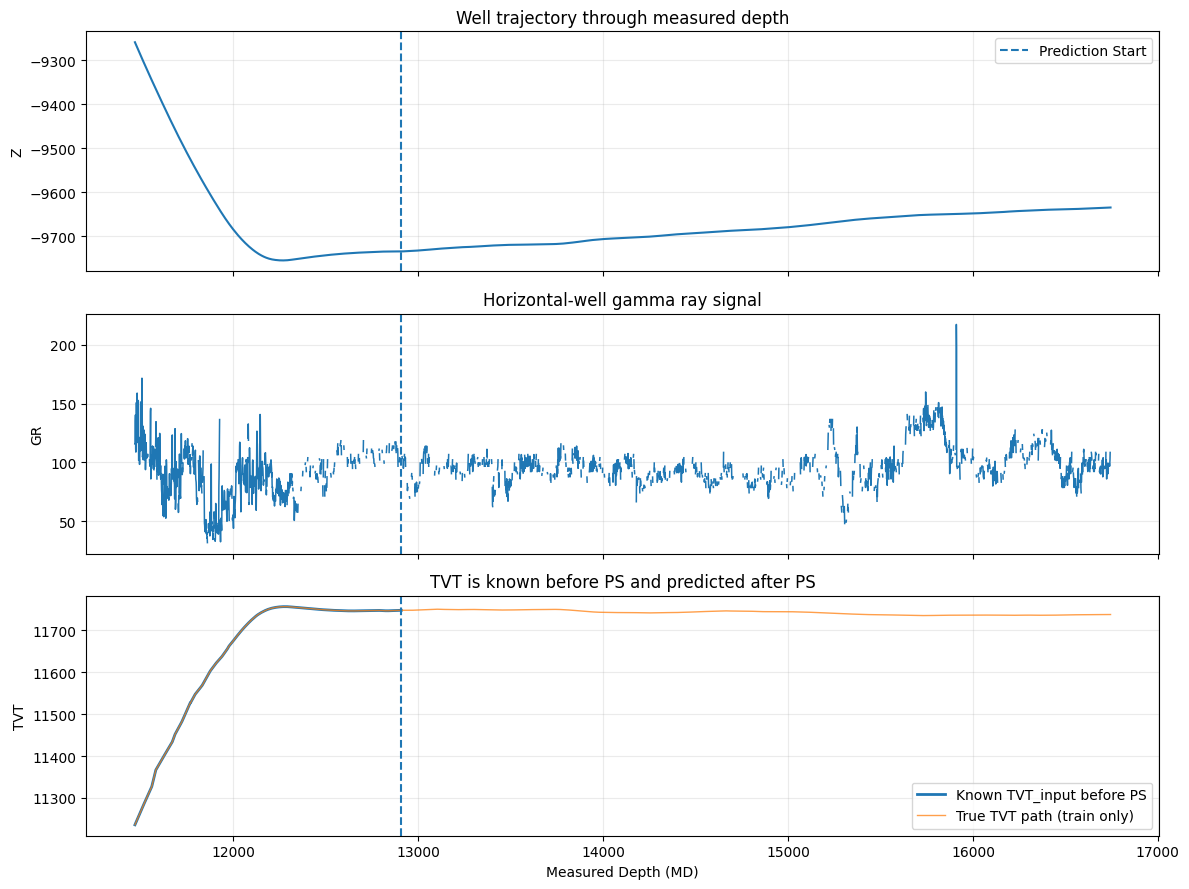

In [3]:
# ============================================================
# Intro 2: visualize trajectory, gamma ray, and known/hidden TVT
# ============================================================

hw = hw_demo.copy()
md = pd.to_numeric(hw.get("MD", pd.Series(np.arange(len(hw)))), errors="coerce")
ps_idx = int(np.where(known_mask.values)[0][-1]) if known_mask.any() else None
ps_md = float(md.iloc[ps_idx]) if ps_idx is not None else np.nan

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# 1) Well trajectory, using Z if available
if "Z" in hw.columns:
    axes[0].plot(md, pd.to_numeric(hw["Z"], errors="coerce"), linewidth=1.5)
    axes[0].set_ylabel("Z")
    axes[0].set_title("Well trajectory through measured depth")
else:
    axes[0].plot(md, np.arange(len(hw)), linewidth=1.5)
    axes[0].set_ylabel("Row index")
    axes[0].set_title("Well path index through measured depth")

# 2) Gamma ray log
if "GR" in hw.columns:
    axes[1].plot(md, pd.to_numeric(hw["GR"], errors="coerce"), linewidth=1.1)
    axes[1].set_ylabel("GR")
    axes[1].set_title("Horizontal-well gamma ray signal")
else:
    axes[1].text(0.5, 0.5, "No GR column found", ha="center", va="center", transform=axes[1].transAxes)

# 3) TVT known/input and hidden target if available
if "TVT_input" in hw.columns:
    axes[2].plot(md[known_mask], hw.loc[known_mask, "TVT_input"], label="Known TVT_input before PS", linewidth=2)
if "TVT" in hw.columns:
    axes[2].plot(md, pd.to_numeric(hw["TVT"], errors="coerce"), label="True TVT path (train only)", linewidth=1, alpha=0.75)
axes[2].set_ylabel("TVT")
axes[2].set_xlabel("Measured Depth (MD)")
axes[2].set_title("TVT is known before PS and predicted after PS")
axes[2].legend(loc="best")

for ax in axes:
    if ps_idx is not None and np.isfinite(ps_md):
        ax.axvline(ps_md, linestyle="--", linewidth=1.5, label="Prediction Start" if ax is axes[0] else None)
    ax.grid(True, alpha=0.25)

if ps_idx is not None:
    axes[0].legend(loc="best")
plt.tight_layout()
plt.show()

## 3. Typewell GR signature and matching logic

Each horizontal well is paired with a vertical typewell. The typewell provides a reference relationship between **TVT** and **GR**. The notebook uses this reference curve, plus the horizontal well's pre-PS known TVT, to estimate where the lateral section sits inside the stratigraphic column.

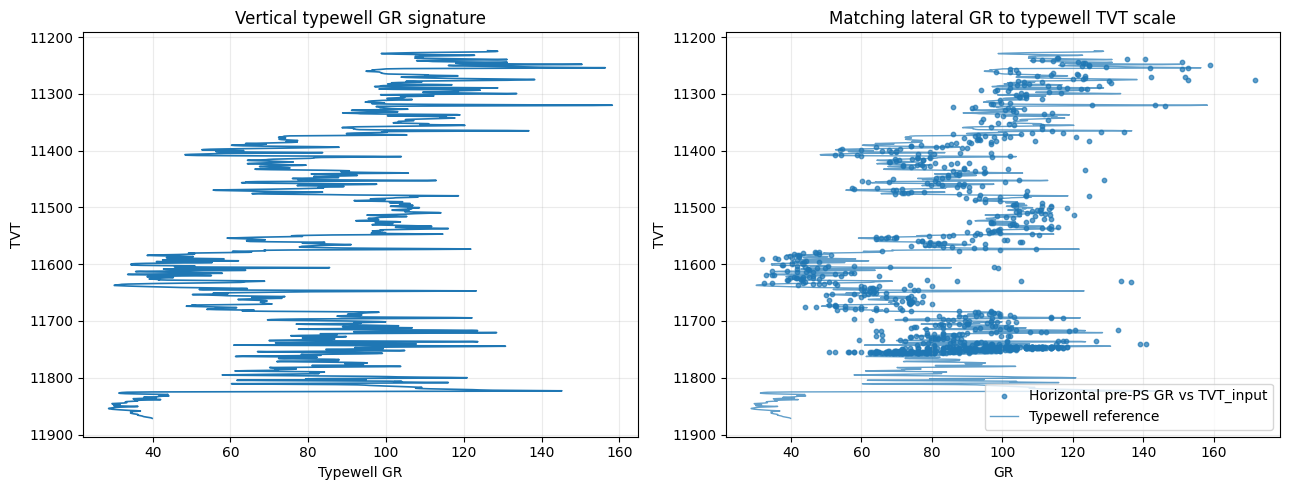

In [4]:
# ============================================================
# Intro 3: compare typewell GR signature with horizontal-well GR
# ============================================================

tw = tw_demo.copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

if {"TVT", "GR"}.issubset(tw.columns):
    tw_tvt = pd.to_numeric(tw["TVT"], errors="coerce")
    tw_gr = pd.to_numeric(tw["GR"], errors="coerce")
    axes[0].plot(tw_gr, tw_tvt, linewidth=1.2)
    axes[0].invert_yaxis()
    axes[0].set_xlabel("Typewell GR")
    axes[0].set_ylabel("TVT")
    axes[0].set_title("Vertical typewell GR signature")
    axes[0].grid(True, alpha=0.25)
else:
    axes[0].text(0.5, 0.5, "Typewell needs TVT and GR columns", ha="center", va="center", transform=axes[0].transAxes)

if {"TVT_input", "GR"}.issubset(hw.columns):
    m = hw["TVT_input"].notna() & hw["GR"].notna()
    axes[1].scatter(hw.loc[m, "GR"], hw.loc[m, "TVT_input"], s=10, alpha=0.7, label="Horizontal pre-PS GR vs TVT_input")
    if {"TVT", "GR"}.issubset(tw.columns):
        axes[1].plot(tw_gr, tw_tvt, linewidth=1.0, alpha=0.7, label="Typewell reference")
    axes[1].invert_yaxis()
    axes[1].set_xlabel("GR")
    axes[1].set_ylabel("TVT")
    axes[1].set_title("Matching lateral GR to typewell TVT scale")
    axes[1].legend(loc="best")
    axes[1].grid(True, alpha=0.25)
else:
    axes[1].text(0.5, 0.5, "Horizontal well needs TVT_input and GR", ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

## 4. Why the residual model matters

The physical base model estimates the TVT path using GR matching, particle filtering, and beam search. The residual model then learns where the base model is systematically wrong.

```text
residual target = actual_TVT - base_pred
final_TVT      = base_pred + alpha × residual_prediction
```

This is useful because the base model captures the geological shape, while the ML layer learns corrections from trajectory, GR residuals, estimator disagreement, offset-well KNN features, and formation-contact context.

Demo well hold-last-known baseline RMSE after PS: 7.454 ft
This baseline is intentionally simple: it predicts no stratigraphic movement after PS.


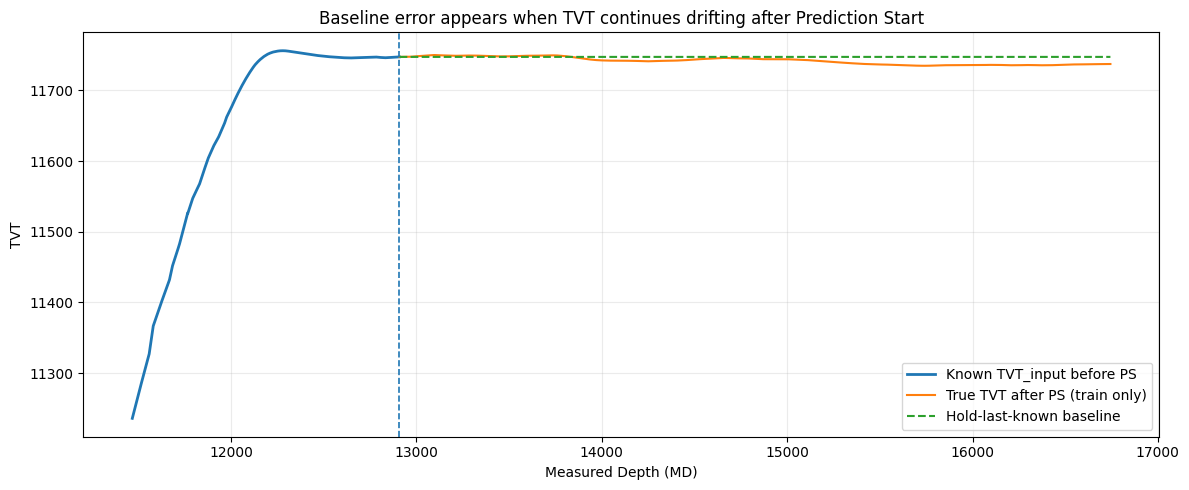

In [5]:
# ============================================================
# Intro 4: show why a hold-last-known baseline is not enough
# ============================================================

if {"TVT", "TVT_input"}.issubset(hw.columns) and known_mask.any() and eval_mask.any():
    last_known_tvt = float(hw.loc[known_mask, "TVT_input"].iloc[-1])
    true_eval = pd.to_numeric(hw.loc[eval_mask, "TVT"], errors="coerce").values.astype(float)
    hold_pred = np.full(len(true_eval), last_known_tvt, dtype=float)
    finite = np.isfinite(true_eval)
    hold_rmse = float(np.sqrt(np.mean((true_eval[finite] - hold_pred[finite]) ** 2))) if finite.any() else np.nan
    print(f"Demo well hold-last-known baseline RMSE after PS: {hold_rmse:.3f} ft")
    print("This baseline is intentionally simple: it predicts no stratigraphic movement after PS.")

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(md[known_mask], hw.loc[known_mask, "TVT_input"], linewidth=2, label="Known TVT_input before PS")
    ax.plot(md[eval_mask], true_eval, linewidth=1.5, label="True TVT after PS (train only)")
    ax.plot(md[eval_mask], hold_pred, linestyle="--", linewidth=1.5, label="Hold-last-known baseline")
    ax.axvline(ps_md, linestyle="--", linewidth=1.2)
    ax.set_title("Baseline error appears when TVT continues drifting after Prediction Start")
    ax.set_xlabel("Measured Depth (MD)")
    ax.set_ylabel("TVT")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()
else:
    print("Training TVT/TVT_input columns are required to compute a baseline RMSE plot.")

## 5. Notebook workflow

The full notebook below runs the production pipeline:

1. **Discover input files robustly** for public/private Kaggle paths.
2. **Generate base predictions** using visible-well contacts, particle-filter GR matching, and beam-search GR matching.
3. **Generate residual features** from GR statistics, typewell offsets, trajectory kinematics, estimator divergence, formation KNN, and row-level ANCC KNN.
4. **Train residual models** using GroupKFold by well with CatBoost, LightGBM, and ExtraTrees fallback.
5. **Tune residual correction** using alpha, clipping, and Cat/LGB blend weights.
6. **Predict test wells** and write a Kaggle-ready `submission.csv`.

In [6]:
# ============================================================
# Intro 5: compact workflow table for a polished project overview
# ============================================================

workflow = pd.DataFrame([
    ["1", "Input discovery", "Find train/test horizontal wells, typewells, and sample_submission across Kaggle/public/private paths."],
    ["2", "Base physical model", "Use contact model, multiscale particle filtering, and beam-search GR matching to estimate base_pred."],
    ["3", "Feature engineering", "Create GR, trajectory, typewell residual, estimator-divergence, and generated KNN geology features."],
    ["4", "Residual dataset", "Train on real-PS, realistic fake-PS, or hybrid tasks with target = actual_TVT - base_pred."],
    ["5", "OOF model training", "Use GroupKFold by well to avoid row leakage and estimate generalization performance."],
    ["6", "Residual blend tuning", "Search CatBoost/LGB weights, alpha multiplier, and residual clipping using OOF RMSE."],
    ["7", "Inference", "For each test well, compute base_pred, build aligned features, predict residuals, smooth, and preserve known TVT_input."],
    ["8", "Submission", "Fill sample_submission ids and export submission.csv."],
], columns=["Step", "Pipeline block", "Purpose"])

display(workflow)

,Step,Pipeline block,Purpose
0,1,Input discovery,"Find train/test horizontal wells, typewells, a..."
1,2,Base physical model,"Use contact model, multiscale particle filteri..."
2,3,Feature engineering,"Create GR, trajectory, typewell residual, esti..."
3,4,Residual dataset,"Train on real-PS, realistic fake-PS, or hybrid..."
4,5,OOF model training,Use GroupKFold by well to avoid row leakage an...
5,6,Residual blend tuning,"Search CatBoost/LGB weights, alpha multiplier,..."
6,7,Inference,"For each test well, compute base_pred, build a..."
7,8,Submission,Fill sample_submission ids and export submissi...


## 6. End-to-end pipeline diagram

The diagram below summarizes how the notebook moves from raw well files to base physical prediction, residual model correction, and final `submission.csv`.

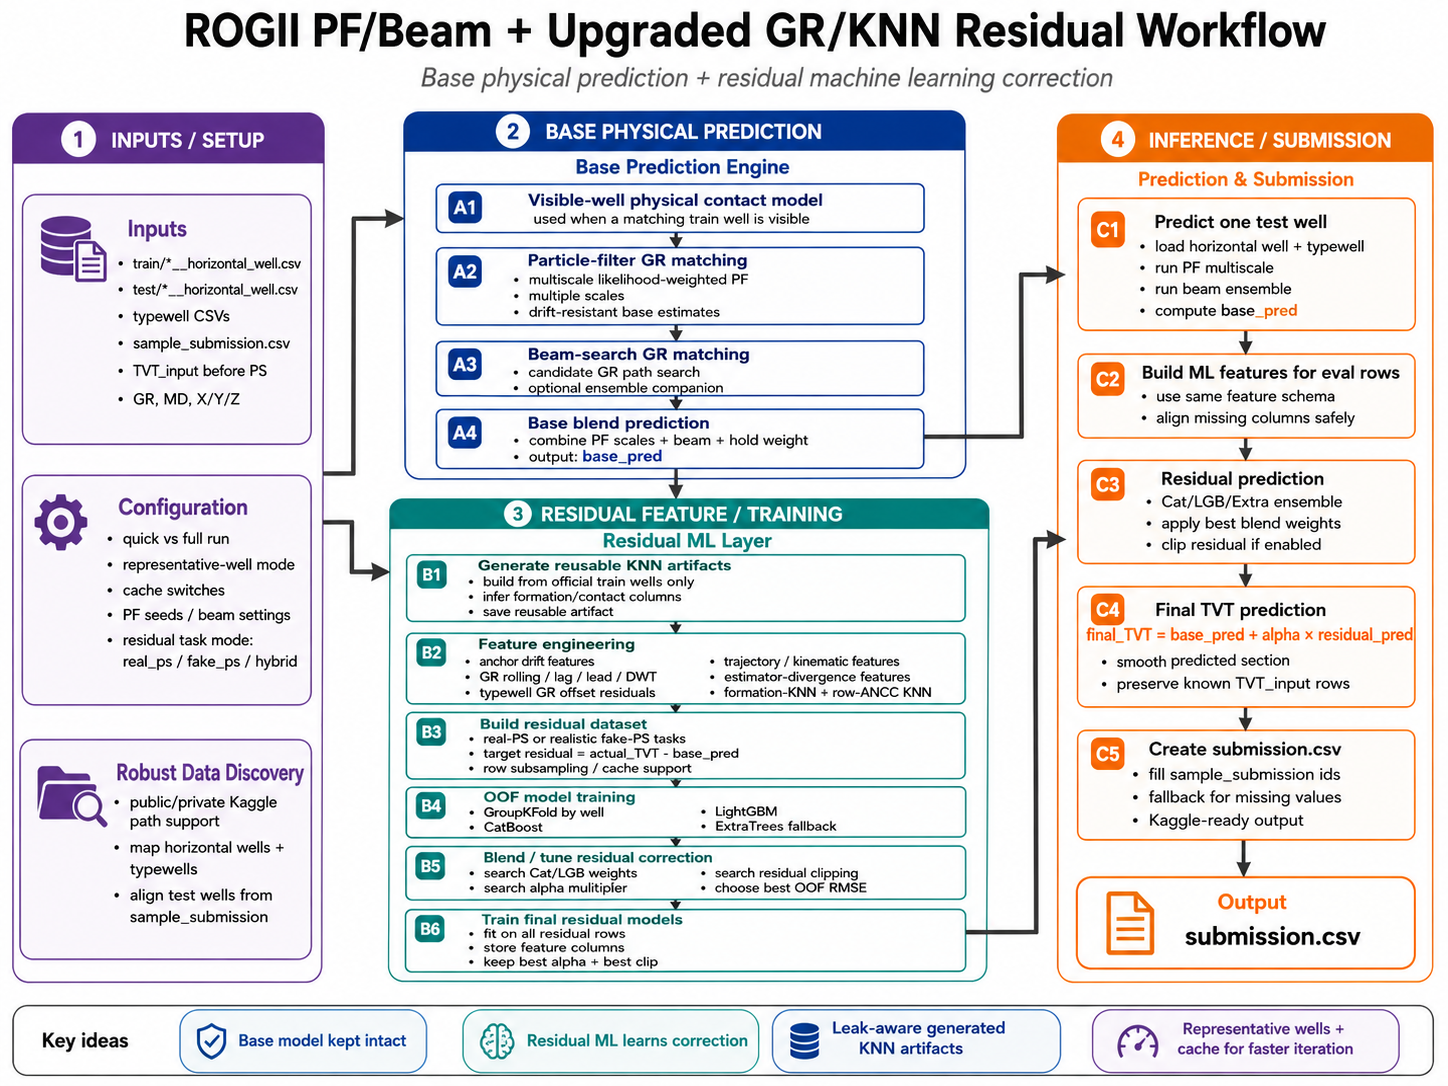

---

# Technical implementation

The remaining cells contain the full modelling pipeline. They are kept separate from the introduction so the notebook reads like a polished project report first, then a reproducible implementation.

# ROGII PF/Beam + Upgraded GR/KNN Feature Residual Model

This notebook keeps the original base-prediction logic intact:

- visible-well physical contact model
- multiscale likelihood-weighted particle-filter prediction
- beam-search GR matching

The upgrade is only in the **ML residual feature layer**. CatBoost/LGBM/ExtraTrees learn a correction:

```text
residual = actual_TVT - base_prediction
final_TVT = base_prediction + alpha * residual_model_prediction
```

Feature upgrades are adapted from the uploaded GR feature/outlier notebook: anchor drift features, GR rolling/lag/lead/DWT features, typewell GR offset residuals, estimator-divergence features, trajectory/kinematic features, generated formation-KNN and row-ANCC KNN features.

No hidden external artifact is required. If KNN-style features are enabled, this notebook builds the artifact from the official `train/*__horizontal_well.csv` files and saves it to Kaggle working output so you can reuse it later.

The competition task provides TVT before the prediction start through `TVT_input`, and scoring is RMSE on the predicted TVT rows.

Updates: 
V1: cache setup (6/5/2026)
V2: Parameters optimization
V3: Base blend optimization

In [1]:
##### ============================================================
# 1. Imports and configuration
# ============================================================

import os
import gc
import glob
import math
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from scipy.signal import savgol_filter
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from tqdm.auto import tqdm
import pickle
import json
import hashlib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

try:
    from catboost import CatBoostRegressor
    USE_CATBOOST = True
except Exception as e:
    USE_CATBOOST = False
    print("CatBoost not available:", repr(e))

try:
    import lightgbm as lgb
    USE_LGBM = True
except Exception as e:
    USE_LGBM = False
    print("LightGBM not available:", repr(e))

try:
    from sklearn.ensemble import ExtraTreesRegressor
    USE_EXTRATREES_FALLBACK = True
except Exception:
    USE_EXTRATREES_FALLBACK = False

try:
    import pywt
    USE_PYWT = True
except Exception as e:
    USE_PYWT = False
    print("PyWavelets not available; DWT features will use rolling fallback:", repr(e))


class CFG:
    # Set QUICK_RUN=False for serious CV/submission runs.
    QUICK_RUN = False
    QUICK_MAX_TRAIN_WELLS = 80
    RANDOM_SEED = 42

    # Representative-well subset for faster full-setting experiments.
    # This lets you run QUICK_RUN=False settings on a stratified subset instead of all 773 wells.
    USE_REPRESENTATIVE_WELLS = True
    REPRESENTATIVE_N_WELLS = 100
    REPRESENTATIVE_N_CLUSTERS = 5
    REPRESENTATIVE_INCLUDE_HARD_WELLS = True
    REPRESENTATIVE_N_HARD_WELLS = 15
    REBUILD_REPRESENTATIVE_WELLS = False
    USE_SAVED_REPRESENTATIVE_LIST = True
    REPRESENTATIVE_CACHE_ROOT = Path("/kaggle/working/cache") if os.path.exists("/kaggle") else Path("cache")
    REPRESENTATIVE_SUMMARY_PATH = REPRESENTATIVE_CACHE_ROOT / "representative_well_summary.csv"
    REPRESENTATIVE_WELL_LIST_PATH = REPRESENTATIVE_CACHE_ROOT / "representative_wells.csv"
    REPRESENTATIVE_HARD_WELLS_PATH = REPRESENTATIVE_CACHE_ROOT / "hard_wells_top.csv"

    # Fake-PS points used to generate residual-training examples.
    # More fractions = better residual training, slower runtime.
    FAKE_PS_FRACS_QUICK = (0.70, 0.80)
    FAKE_PS_FRACS_FULL = (0.70, 0.80, 0.90)

    # Realistic fake-PS: place fake PS inside the original TVT_input known section
    # instead of giving the model known TVT from arbitrary future rows.
    USE_REALISTIC_FAKE_PS = True
    FAKE_PS_MIN_KNOWN_ROWS = 40
    FAKE_PS_MIN_EVAL_ROWS = 20
    FAKE_PS_MIN_GAP_TO_REAL_PS = 10

    # PF settings. Full settings are still much cheaper than 128 seeds for every fake-PS example.
    PF_PARTICLES_QUICK = 250 #250
    PF_SEEDS_OOF_QUICK = 16 #8
    PF_SEEDS_SUBMIT_QUICK = 32 #16

    PF_PARTICLES_FULL = 250
    PF_SEEDS_OOF_FULL = 32
    PF_SEEDS_SUBMIT_FULL = 64

    PF_SCALES = (2.0, 3.0, 5.0, 8.0, 12.0, 16.0)

    # Base blend before ML residual correction.
    BASE_SCALE = 4.0
    DEFAULT_BEAM_WEIGHT = 0.10
    DEFAULT_HOLD_WEIGHT = 0.05

    # Beam search can be expensive, but it often improves difficult wells.
    USE_BEAM = True

    # ML training.
    N_SPLITS = 5
    CAT_ITERATIONS_QUICK = 1000 #2500
    CAT_ITERATIONS_FULL = 2500
    LGB_ROUNDS_QUICK = 1000 #2500
    LGB_ROUNDS_FULL = 2500

    # Use a conservative residual multiplier chosen by OOF alpha search.
    # The code searches alpha automatically, but these are the candidates.
    RESIDUAL_ALPHA_GRID = np.round(np.arange(0.0, 1.01, 0.025), 3)
    RESIDUAL_CLIP_GRID = (5.0, 8.0, 10.0, 12.0, 15.0)
    APPLY_RESIDUAL_CLIPPING = True

    # Upgraded feature artifact generation. This uses only official train horizontal_well files.
    USE_GENERATED_KNN_FEATURES = True
    FORCE_REBUILD_GENERATED_ARTIFACTS = False
    GENERATED_ARTIFACT_PATH = Path('/kaggle/working/rogii_generated_feature_artifacts.pkl') if os.path.exists('/kaggle') else Path('rogii_generated_feature_artifacts.pkl')
    FORMATION_K = 15
    ROW_KNN_K = 24
    ROW_KNN_STRIDE_QUICK = 75 #75
    ROW_KNN_STRIDE_FULL = 40
    SAVE_GENERATED_DATASETS = True

    # Residual-row cache.
    # This saves each processed residual task as soon as it is built, so reruns can resume
    # instead of rebuilding PF/beam/features for all wells.
    USE_RESIDUAL_ROW_CACHE = True
    REBUILD_RESIDUAL_ROW_CACHE = False
    RESIDUAL_FEATURE_CACHE_TAG = "v5_realps_update_cache1"
    RESIDUAL_CACHE_VERSION = "auto"  # keep "auto" unless you intentionally want a manual cache folder
    RESIDUAL_CACHE_AUTO_FINGERPRINT = True

    # External cache dataset, read first. Change foldername to your own Kaggle Dataset folder.
    # The notebook will look here first, but it will never try to write to /kaggle/input.
    # Accepted layouts inside this folder:
    #   cache/residual_rows/<version>/...
    #   residual_rows/<version>/...
    #   <version>/...
    #   real_ps/*.parquet or fake_ps/*.parquet directly inside the folder
    USE_EXTERNAL_RESIDUAL_ROW_CACHE = True
    READ_EXTERNAL_RESIDUAL_CACHE_FIRST = True
    EXTERNAL_RESIDUAL_CACHE_ROOT = Path("/kaggle/input/datasets/pannchobkitchakarn/pann-cache") if os.path.exists("/kaggle") else Path("external_cache/foldername")

    # New cache files are always written here. If the external dataset has no matching files,
    # the notebook builds the missing cache files in this working folder.
    RESIDUAL_CACHE_ROOT = Path("/kaggle/working/cache") if os.path.exists("/kaggle") else Path("cache")

    # Residual training task generation.
    # "real_ps" is fastest and most representative: use the original train TVT_input PS once per well.
    # "fake_ps" is the older multi-fraction synthetic setup.
    # "hybrid" uses real-PS rows plus fake-PS rows.
    RESIDUAL_TASK_MODE = "real_ps"  # options: "real_ps", "fake_ps", "hybrid"
    USE_ROW_SUBSAMPLING_FOR_RESIDUAL_TRAIN = True
    MAX_RESIDUAL_ROWS_PER_TASK_QUICK = 1200
    MAX_RESIDUAL_ROWS_PER_TASK_FULL = 2000
    MIN_REAL_PS_EVAL_ROWS = 20

    # If a test well is also present in train, use the physical contact model.
    # Set this False if you want pure PF/beam+ML for every test well.
    USE_VISIBLE_WELL_PHYSICAL_MODEL = True

    # Submission smoothing. Tune/disable if leaderboard gets worse.
    SMOOTH_SUBMISSION = False
    SMOOTH_BLEND = 0.15
    SMOOTH_WINDOW = 31
    SMOOTH_POLY = 2


if CFG.QUICK_RUN:
    FAKE_PS_FRACS = CFG.FAKE_PS_FRACS_QUICK
    PF_PARTICLES = CFG.PF_PARTICLES_QUICK
    PF_SEEDS_OOF = CFG.PF_SEEDS_OOF_QUICK
    PF_SEEDS_SUBMIT = CFG.PF_SEEDS_SUBMIT_QUICK
    CAT_ITERATIONS = CFG.CAT_ITERATIONS_QUICK
    LGB_ROUNDS = CFG.LGB_ROUNDS_QUICK
    MAX_RESIDUAL_ROWS_PER_TASK = CFG.MAX_RESIDUAL_ROWS_PER_TASK_QUICK
else:
    FAKE_PS_FRACS = CFG.FAKE_PS_FRACS_FULL
    PF_PARTICLES = CFG.PF_PARTICLES_FULL
    PF_SEEDS_OOF = CFG.PF_SEEDS_OOF_FULL
    PF_SEEDS_SUBMIT = CFG.PF_SEEDS_SUBMIT_FULL
    CAT_ITERATIONS = CFG.CAT_ITERATIONS_FULL
    LGB_ROUNDS = CFG.LGB_ROUNDS_FULL
    MAX_RESIDUAL_ROWS_PER_TASK = CFG.MAX_RESIDUAL_ROWS_PER_TASK_FULL

ROW_KNN_STRIDE = CFG.ROW_KNN_STRIDE_QUICK if CFG.QUICK_RUN else CFG.ROW_KNN_STRIDE_FULL

print("USE_CATBOOST:", USE_CATBOOST)
print("USE_LGBM:", USE_LGBM)
print("QUICK_RUN:", CFG.QUICK_RUN)
print("FAKE_PS_FRACS:", FAKE_PS_FRACS)
print("USE_REALISTIC_FAKE_PS:", CFG.USE_REALISTIC_FAKE_PS)
print("PF_PARTICLES:", PF_PARTICLES)
print("PF_SEEDS_OOF:", PF_SEEDS_OOF)
print("PF_SEEDS_SUBMIT:", PF_SEEDS_SUBMIT)
print("RESIDUAL_TASK_MODE:", CFG.RESIDUAL_TASK_MODE)
print("MAX_RESIDUAL_ROWS_PER_TASK:", MAX_RESIDUAL_ROWS_PER_TASK)
print("USE_GENERATED_KNN_FEATURES:", CFG.USE_GENERATED_KNN_FEATURES)
print("ROW_KNN_STRIDE:", ROW_KNN_STRIDE)

USE_CATBOOST: True
USE_LGBM: True
QUICK_RUN: False
FAKE_PS_FRACS: (0.7, 0.8, 0.9)
USE_REALISTIC_FAKE_PS: True
PF_PARTICLES: 250
PF_SEEDS_OOF: 32
PF_SEEDS_SUBMIT: 64
RESIDUAL_TASK_MODE: real_ps
MAX_RESIDUAL_ROWS_PER_TASK: 2000
USE_GENERATED_KNN_FEATURES: True
ROW_KNN_STRIDE: 40


In [2]:
# ============================================================
# 2. Locate competition/public/private inputs robustly
# ============================================================

import re
from collections import OrderedDict


def _path_priority(p):
    """Lower priority value is preferred when duplicate files exist."""
    s = str(p)
    pri = 100
    if "/competitions/rogii-wellbore-geology-prediction" in s:
        pri = 0
    elif "/rogii-wellbore-geology-prediction" in s:
        pri = 1
    elif "/kaggle/input" in s:
        pri = 5
    elif "/mnt/data" in s:
        pri = 20
    return (pri, len(s), s)


def discover_input_roots():
    roots = []
    candidates = [
        Path("/kaggle/input/competitions/rogii-wellbore-geology-prediction"),
        Path("/kaggle/input/rogii-wellbore-geology-prediction"),
        Path("/mnt/data"),
    ]
    for c in candidates:
        if c.exists():
            roots.append(c)

    # Include every Kaggle dataset root; private/public added datasets may be elsewhere.
    kg = Path("/kaggle/input")
    if kg.exists():
        for p in kg.iterdir():
            if p.is_dir():
                roots.append(p)
        # Also include nested roots containing sample/train/test in competitions style.
        roots.extend(Path(x).parent for x in glob.glob("/kaggle/input/**/sample_submission.csv", recursive=True))

    # De-duplicate while preserving order.
    out = []
    seen = set()
    for r in roots:
        r = Path(r).resolve()
        if str(r) not in seen:
            seen.add(str(r))
            out.append(r)
    return out


def choose_sample_submission(roots):
    hits = []
    for r in roots:
        hits.extend(r.glob("sample_submission.csv"))
        hits.extend(r.glob("**/sample_submission.csv"))
    hits = sorted(set(hits), key=_path_priority)
    if not hits:
        raise FileNotFoundError("Cannot locate sample_submission.csv under /kaggle/input or /mnt/data")
    return hits[0]


def _well_from_hw_path(path):
    return Path(path).name.split("__")[0]


def _build_hw_map(roots, split):
    """Build map well_id -> horizontal_well path across all official/private roots."""
    found = []
    patterns = [f"{split}/*__horizontal_well.csv", f"**/{split}/*__horizontal_well.csv"]
    if split == "test":
        patterns += ["*__horizontal_well.csv", "**/*__horizontal_well.csv"]
    for r in roots:
        for pat in patterns:
            found.extend(r.glob(pat))
    # For train, avoid accidentally taking test/demo files not inside train.
    if split == "train":
        found = [p for p in found if f"/{split}/" in str(p).replace("\\", "/")]

    found = sorted(set(found), key=_path_priority)
    mp = OrderedDict()
    for p in found:
        wid = _well_from_hw_path(p)
        if wid not in mp:
            mp[wid] = Path(p)
    return dict(mp)


def _find_typewell_for_hw(hw_path):
    hw_path = Path(hw_path)
    wid = hw_path.name.split("__")[0]
    folder = hw_path.parent
    candidates = sorted(folder.glob(f"{wid}__typewell*.csv"), key=_path_priority)
    if candidates:
        return candidates[0]
    # Fallback: search near the same root if structure is unusual.
    root = folder.parent if folder.name in ("train", "test") else folder
    candidates = sorted(root.glob(f"**/{wid}__typewell*.csv"), key=_path_priority)
    if candidates:
        return candidates[0]
    return None


def build_typewell_map(hw_map):
    tw_map = {}
    missing = []
    for wid, hw_path in hw_map.items():
        tw = _find_typewell_for_hw(hw_path)
        if tw is None:
            missing.append(wid)
        else:
            tw_map[wid] = tw
    if missing:
        print(f"WARNING: {len(missing)} wells have no matching typewell file. First missing: {missing[:5]}")
    return tw_map


def parse_submission_ids(sample_df):
    ids = sample_df["id"].astype(str)
    wells = []
    row_idxs = []
    bad = []
    for s in ids:
        m = re.match(r"^(.+?)_(\d+)$", s)
        if m:
            wells.append(m.group(1))
            row_idxs.append(int(m.group(2)))
        else:
            # Competition ids are usually 8-char well id + '_' + row index.
            wells.append(s[:8])
            try:
                row_idxs.append(int(s[9:]))
            except Exception:
                bad.append(s)
                row_idxs.append(-1)
    if bad:
        print(f"WARNING: could not parse {len(bad)} submission ids. First bad ids: {bad[:5]}")
    sample_df = sample_df.copy()
    sample_df["well"] = wells
    sample_df["row_idx"] = row_idxs
    return sample_df


INPUT_ROOTS = discover_input_roots()
print("Discovered input roots:")
for r in INPUT_ROOTS[:20]:
    print("  ", r)
if len(INPUT_ROOTS) > 20:
    print(f"  ... {len(INPUT_ROOTS) - 20} more")

sample_path = choose_sample_submission(INPUT_ROOTS)
INPUT_DIR = str(sample_path.parent)
TRAIN_DIR = os.path.join(INPUT_DIR, "train")
TEST_DIR = os.path.join(INPUT_DIR, "test")
print(f"sample_submission={sample_path}")

sample = pd.read_csv(sample_path)
if "id" not in sample.columns:
    raise ValueError("sample_submission.csv must contain an id column")
sample = parse_submission_ids(sample)

TRAIN_HW_MAP = _build_hw_map(INPUT_ROOTS, "train")
TEST_HW_MAP = _build_hw_map(INPUT_ROOTS, "test")
TRAIN_TW_MAP = build_typewell_map(TRAIN_HW_MAP)
TEST_TW_MAP = build_typewell_map(TEST_HW_MAP)

# Train wells require both horizontal and typewell files.
TRAIN_WELLS = sorted([w for w in TRAIN_HW_MAP if w in TRAIN_TW_MAP])

# Use sample_submission as the source of truth for submission wells.
SAMPLE_WELLS = list(dict.fromkeys(sample["well"].astype(str).tolist()))
TEST_WELLS = [w for w in SAMPLE_WELLS if w in TEST_HW_MAP and w in TEST_TW_MAP]
missing_sample_wells = [w for w in SAMPLE_WELLS if w not in TEST_HW_MAP or w not in TEST_TW_MAP]
if missing_sample_wells:
    print(f"WARNING: {len(missing_sample_wells)} sample wells missing test files. First: {missing_sample_wells[:10]}")

extra_test_wells = [w for w in TEST_HW_MAP if w not in set(SAMPLE_WELLS)]
if extra_test_wells:
    print(f"INFO: ignoring {len(extra_test_wells)} extra test wells not present in sample_submission. First: {extra_test_wells[:10]}")

print("sample shape:", sample.shape)
print(sample.head())
print("n train wells:", len(TRAIN_WELLS))
print("n sample wells:", len(SAMPLE_WELLS))
print("n usable test wells:", len(TEST_WELLS))
print("first train wells:", TRAIN_WELLS[:5])
print("test wells:", TEST_WELLS[:10])


Discovered input roots:
   /kaggle/input/competitions/rogii-wellbore-geology-prediction
   /kaggle/input/competitions
   /kaggle/input/datasets
sample_submission=/kaggle/input/competitions/rogii-wellbore-geology-prediction/sample_submission.csv
INFO: ignoring 770 extra test wells not present in sample_submission. First: ['015fe0d2', '01869cd4', '01982c1d', '028d7b28', '02e7fe5a', '0390d174', '03a935ae', '044af7d1', '0498acab', '052d64df']
sample shape: (14151, 4)
              id  tvt      well  row_idx
0  000d7d20_1442  0.0  000d7d20     1442
1  000d7d20_1443  0.0  000d7d20     1443
2  000d7d20_1444  0.0  000d7d20     1444
3  000d7d20_1445  0.0  000d7d20     1445
4  000d7d20_1446  0.0  000d7d20     1446
n train wells: 773
n sample wells: 3
n usable test wells: 3
first train wells: ['000d7d20', '00bbac68', '00e12e8b', '015fe0d2', '01869cd4']
test wells: ['000d7d20', '00bbac68', '00e12e8b']


In [3]:
# ============================================================
# 3. Basic IO and metrics
# ============================================================

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    if m.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((y_true[m] - y_pred[m]) ** 2)))


def load_well(wid, split="train"):
    """Load a well from robust file maps, supporting public/private Kaggle dataset layouts."""
    wid = str(wid)
    if split == "train":
        hw_map, tw_map = TRAIN_HW_MAP, TRAIN_TW_MAP
    else:
        hw_map, tw_map = TEST_HW_MAP, TEST_TW_MAP
    if wid not in hw_map:
        raise FileNotFoundError(f"No {split} horizontal_well file found for well {wid}")
    if wid not in tw_map:
        raise FileNotFoundError(f"No {split} typewell file found for well {wid}")
    hw = pd.read_csv(hw_map[wid])
    tw = pd.read_csv(tw_map[wid])
    return hw, tw


def sort_by_md_if_needed(hw):
    # Most competition files are already in correct row order. Keep original index as row_idx.
    hw = hw.copy()
    hw["row_idx"] = np.arange(len(hw), dtype=np.int64)
    return hw


def prepare_typewell(tw):
    """Prepare typewell arrays with duplicate/invalid TVT protection and stable GR derivative."""
    tws = tw.copy()
    if "TVT" not in tws.columns or "GR" not in tws.columns:
        raise ValueError("Typewell file must contain TVT and GR columns")
    tws["TVT"] = pd.to_numeric(tws["TVT"], errors="coerce")
    tws["GR"] = pd.to_numeric(tws["GR"], errors="coerce")
    tws = tws.dropna(subset=["TVT"]).sort_values("TVT").reset_index(drop=True)
    if len(tws) == 0:
        raise ValueError("Typewell has no finite TVT values")

    # Drop duplicate TVT values before np.interp / gradient. Duplicates can make derivatives explode.
    tws = tws.drop_duplicates(subset=["TVT"], keep="first").reset_index(drop=True)
    tw_tvt = tws["TVT"].values.astype(float)

    # Interpolate typewell GR instead of mean-filling; mean-fill creates false flat sections.
    tw_gr_ser = tws["GR"].astype(float).interpolate(limit_direction="both")
    if np.isfinite(tw_gr_ser.values).any():
        tw_gr_ser = tw_gr_ser.fillna(float(np.nanmedian(tw_gr_ser.values)))
    else:
        tw_gr_ser = tw_gr_ser.fillna(0.0)
    tw_gr = tw_gr_ser.values.astype(float)

    if len(tw_tvt) > 2 and np.nanmax(tw_tvt) > np.nanmin(tw_tvt):
        with np.errstate(divide="ignore", invalid="ignore"):
            tw_dgr = np.gradient(tw_gr, tw_tvt)
        tw_dgr = np.nan_to_num(tw_dgr, nan=0.0, posinf=0.0, neginf=0.0)
        tw_dgr = np.clip(tw_dgr, -50.0, 50.0)
    else:
        tw_dgr = np.zeros_like(tw_gr)

    geology = None
    if "Geology" in tws.columns:
        geology = tws["Geology"].astype(str).fillna("UNK").values

    return tws, tw_tvt, tw_gr, tw_dgr, geology


def _first_contiguous_known_end(known_mask):
    """Return last row of the initial contiguous known TVT_input block."""
    known_mask = np.asarray(known_mask, dtype=bool)
    if len(known_mask) == 0 or not known_mask[0]:
        idx = np.flatnonzero(known_mask)
        return int(idx[-1]) if len(idx) else -1
    first_gap = np.flatnonzero(~known_mask)
    return int(first_gap[0] - 1) if len(first_gap) else int(len(known_mask) - 1)


def make_fake_ps(hw, frac):
    """
    Create a realistic synthetic prediction task from a training well.

    Previous version:
      - used cut = frac * full well length
      - filled TVT_input with true TVT before that arbitrary cut

    Improved version:
      - if the file has a real TVT_input known section, place the fake PS inside that
        original known section only
      - hide everything after the fake PS
      - evaluate against true TVT after the fake PS

    This prevents fake-PS training from giving the PF/beam tracker future TVT_input
    that would not be available at real test time.
    """
    hw = sort_by_md_if_needed(hw).reset_index(drop=True)
    if "TVT" not in hw.columns:
        raise ValueError("Training horizontal well must contain TVT")

    n = len(hw)
    if n < 2 * CFG.FAKE_PS_MIN_EVAL_ROWS + 5:
        raise ValueError(f"Well too short for fake-PS: n={n}")

    tvt_true = hw["TVT"].astype(float).values
    finite_tvt = np.isfinite(tvt_true)

    used_real_tvt_input = False
    real_ps_last_row = -1

    if CFG.USE_REALISTIC_FAKE_PS and "TVT_input" in hw.columns:
        original_known = hw["TVT_input"].notna().values & finite_tvt
        real_ps_last_row = _first_contiguous_known_end(original_known)

        # Use original known section only if it is long enough to create a fake PS
        # and still leave a gap before the real PS.
        min_needed = max(CFG.FAKE_PS_MIN_KNOWN_ROWS, CFG.FAKE_PS_MIN_EVAL_ROWS + CFG.FAKE_PS_MIN_GAP_TO_REAL_PS)
        if real_ps_last_row >= min_needed:
            upper = max(CFG.FAKE_PS_MIN_EVAL_ROWS + 1, real_ps_last_row - CFG.FAKE_PS_MIN_GAP_TO_REAL_PS)
            raw_cut = int(round((real_ps_last_row + 1) * float(frac)))
            cut = int(np.clip(raw_cut, CFG.FAKE_PS_MIN_EVAL_ROWS, upper))
            used_real_tvt_input = True
        else:
            cut = int(np.clip(round(n * float(frac)), CFG.FAKE_PS_MIN_EVAL_ROWS, n - CFG.FAKE_PS_MIN_EVAL_ROWS))
    else:
        cut = int(np.clip(round(n * float(frac)), CFG.FAKE_PS_MIN_EVAL_ROWS, n - CFG.FAKE_PS_MIN_EVAL_ROWS))

    # Build fake input: only TVT before the fake PS is visible.
    hw_fake = hw.copy()
    hw_fake["TVT_input"] = np.nan
    hw_fake.loc[:cut - 1, "TVT_input"] = tvt_true[:cut]

    # Diagnostic columns are not used as ML features; they are dropped in get_feature_columns.
    hw_fake["fake_ps_cut_row_internal"] = int(cut)
    hw_fake["fake_ps_real_ps_last_row_internal"] = int(real_ps_last_row)
    hw_fake["fake_ps_used_original_tvt_input_internal"] = int(used_real_tvt_input)

    val_mask = np.zeros(n, dtype=bool)
    val_mask[cut:] = True
    val_mask &= finite_tvt

    if val_mask.sum() < CFG.FAKE_PS_MIN_EVAL_ROWS:
        raise ValueError(f"Too few fake-PS eval rows: {val_mask.sum()}")

    return hw_fake, val_mask, cut


def tvt_from_contacts(hw_tr, tw_tr, ref_col="EGFDU"):
    """Physical contact model for test wells that are also visible in train."""
    tw_g = tw_tr.dropna(subset=["Geology"]).copy() if "Geology" in tw_tr.columns else tw_tr.copy()
    if ref_col not in hw_tr.columns:
        numeric_cols = [c for c in hw_tr.columns if c not in ["TVT", "TVT_input", "MD", "X", "Y", "Z", "GR"] and pd.api.types.is_numeric_dtype(hw_tr[c])]
        if not numeric_cols:
            return None
        ref_col = numeric_cols[0]

    if "Geology" in tw_g.columns and (tw_g["Geology"] == ref_col).any():
        ref_tvt = tw_g.loc[tw_g["Geology"] == ref_col, "TVT"].min()
    else:
        ref_tvt = tw_g["TVT"].min()

    if not np.isfinite(ref_tvt):
        return None

    offset = (hw_tr["TVT"] - (ref_tvt - (hw_tr["Z"] - hw_tr[ref_col]))).mean()
    return ref_tvt - (hw_tr["Z"] - hw_tr[ref_col]) + offset

In [4]:
# ============================================================
# 4. Particle filter GR matching
# ============================================================

def run_particle_filter(hw, tw, n_particles=500, seed=42, use_gr_derivative=True):
    """
    Conservative particle filter tracker.
    Returns predicted TVT for every row and a total log-likelihood score.
    """
    hw = hw.copy().reset_index(drop=True)
    _, tw_tvt, tw_gr, tw_dgr, _ = prepare_typewell(tw)

    kn = hw[hw["TVT_input"].notna()].copy()
    ev = hw[hw["TVT_input"].isna()].copy()

    out_vals = hw["TVT_input"].values.astype(float).copy()
    if len(ev) == 0:
        return out_vals, 0.0
    if len(kn) == 0:
        fill = float(np.nanmedian(tw_tvt))
        out_vals[:] = fill
        return out_vals, -1e9

    last = kn.iloc[-1]
    last_tvt = float(last["TVT_input"])
    last_z = float(last["Z"])
    last_md = float(last["MD"])

    tw_at_k = np.interp(kn["TVT_input"].values.astype(float), tw_tvt, tw_gr)
    gr_known = kn["GR"].values.astype(float) if "GR" in kn.columns else np.full(len(kn), np.nan)
    good = np.isfinite(gr_known) & np.isfinite(tw_at_k)
    if good.sum() >= 20:
        gs = float(np.clip(np.nanstd(gr_known[good] - tw_at_k[good]), 10.0, 60.0))
    else:
        gs = 25.0

    tail = kn.tail(min(40, len(kn)))
    dt = np.diff(tail["TVT_input"].values.astype(float))
    dz = np.diff(tail["Z"].values.astype(float))
    dm = np.diff(tail["MD"].values.astype(float))
    m = dm > 0
    init_rate = float(np.median((dt + dz)[m] / dm[m])) if m.sum() >= 3 else 0.0

    eval_z = ev["Z"].values.astype(float)
    z_span = float(np.nanmax(eval_z) - np.nanmin(eval_z)) if len(eval_z) else 0.0
    gr_eval = ev["GR"].values.astype(float) if "GR" in ev.columns else np.full(len(ev), np.nan)
    nan_frac = float(np.mean(~np.isfinite(gr_eval))) if len(gr_eval) else 0.0

    if z_span > 180 or nan_frac > 0.35:
        MOM, VN, PN, RP, RR, RESAMP = 0.997, 0.0040, 0.0100, 0.20, 0.0020, 0.50
    else:
        MOM, VN, PN, RP, RR, RESAMP = 0.998, 0.0015, 0.0040, 0.08, 0.0010, 0.50

    N = int(n_particles)
    rng = np.random.default_rng(seed)
    pos = last_tvt + last_z + 2.0 * rng.standard_normal(N)
    rate = init_rate + 0.01 * rng.standard_normal(N)
    w = np.ones(N, dtype=float) / N

    md_v = ev["MD"].values.astype(float)
    z_v = ev["Z"].values.astype(float)

    if "GR" in hw.columns:
        gr_interp = hw["GR"].astype(float).interpolate(limit_direction="both").fillna(float(np.nanmedian(tw_gr)))
    else:
        gr_interp = pd.Series(np.full(len(hw), float(np.nanmedian(tw_gr))))
    gr_all = gr_interp.values.astype(float)
    gr_v = gr_all[ev.index.values]

    if use_gr_derivative and len(gr_all) > 2:
        md_all = hw["MD"].values.astype(float)
        md_safe = md_all.copy()
        for i in range(1, len(md_safe)):
            if md_safe[i] <= md_safe[i-1]:
                md_safe[i] = md_safe[i-1] + 1e-3
        h_dgr_all = np.gradient(gr_all, md_safe)
        h_dgr_v = h_dgr_all[ev.index.values]
        finite_d = h_dgr_all[np.isfinite(h_dgr_all)]
        gds = float(np.clip(np.nanstd(finite_d), 0.05, 10.0)) if len(finite_d) else 1.0
    else:
        h_dgr_v = np.zeros(len(ev), dtype=float)
        gds = 1.0

    res = np.empty(len(ev), dtype=float)
    prev_md = last_md
    log_lik = 0.0

    for i in range(len(ev)):
        dm_step = max(md_v[i] - prev_md, 1.0)
        rate = MOM * rate + VN * rng.standard_normal(N)
        pos = pos + rate * dm_step + PN * rng.standard_normal(N)

        tvt_p = pos - z_v[i]
        tvt_p = np.clip(tvt_p, tw_tvt[0] - 100.0, tw_tvt[-1] + 100.0)
        pos = tvt_p + z_v[i]

        eg = np.interp(tvt_p, tw_tvt, tw_gr)
        d_raw = (gr_v[i] - eg) / gs

        if use_gr_derivative:
            eg_d = np.interp(tvt_p, tw_tvt, tw_dgr)
            d_grad = (h_dgr_v[i] - eg_d) / gds
            score = 0.80 * np.minimum(d_raw ** 2, 600.0) + 0.20 * np.minimum(d_grad ** 2, 600.0)
        else:
            score = np.minimum(d_raw ** 2, 600.0)

        lk = np.exp(-0.5 * score)
        lk = np.maximum(lk, 1e-300)

        avg_lk = float((w * lk).sum())
        log_lik += math.log(max(avg_lk, 1e-300))

        w *= lk
        ws = w.sum()
        if ws > 0 and np.isfinite(ws):
            w /= ws
        else:
            w[:] = 1.0 / N

        n_eff = 1.0 / np.sum(w ** 2)
        if n_eff < RESAMP * N:
            cum = np.cumsum(w)
            u0 = rng.uniform(0, 1.0 / N)
            idx = np.clip(np.searchsorted(cum, u0 + np.arange(N) / N), 0, N - 1)
            pos = pos[idx] + RP * rng.standard_normal(N)
            rate = rate[idx] + RR * rng.standard_normal(N)
            w[:] = 1.0 / N

        res[i] = float(np.dot(w, pos - z_v[i]))
        prev_md = md_v[i]

    out_vals[ev.index.values] = res
    return out_vals, log_lik


def run_pf_lik_ensemble_scales(hw, tw, scales=CFG.PF_SCALES, n_particles=500, n_seeds=32):
    preds = []
    liks = []
    for s in range(int(n_seeds)):
        p, ll = run_particle_filter(hw, tw, n_particles=n_particles, seed=s, use_gr_derivative=True)
        preds.append(p)
        liks.append(ll)

    pred_arr = np.stack(preds, axis=0)
    liks = np.asarray(liks, dtype=float)
    liks_n = liks - np.nanmax(liks)

    out = {}
    for scale in scales:
        weights = np.exp(liks_n / float(scale))
        weights_sum = weights.sum()
        weights = weights / weights_sum if weights_sum > 0 else np.ones_like(weights) / len(weights)
        out[f"pf_scale_{scale:g}"] = (weights[:, None] * pred_arr).sum(axis=0)

    out["pf_mean"] = pred_arr.mean(axis=0)
    out["pf_std"] = pred_arr.std(axis=0)
    return out

In [5]:
# ============================================================
# 5. Beam-search GR matching
# ============================================================
'''''
BEAM_CONFIGS = [
    (10, 20.0, 144.0, 2),
    (10,  8.0,  64.0, 2),
    ( 8, 35.0, 220.0, 1),
    (10, 14.0,  90.0, 5),
    (20,  4.0,  36.0, 3),
    (12, 12.0, 100.0, 3),
    (15, 25.0, 180.0, 2),
    (20, 30.0, 200.0, 2),
    (15, 10.0,  80.0, 4),
    (25,  6.0,  50.0, 3),
    (10, 40.0, 300.0, 1),
    (12, 18.0, 120.0, 5),
    (30,  8.0,  70.0, 2),
    (10, 50.0, 400.0, 0),
]
'''''
BEAM_CONFIGS = [
    # Balanced GR-following
    (10, 10.0,  80.0, 2),
    (10, 14.0, 100.0, 2),
    (12, 18.0, 120.0, 2),

    # Smoother / conservative paths
    (10, 25.0, 180.0, 2),
    (12, 35.0, 220.0, 1),

    # Sharper GR-following paths
    (15,  6.0,  50.0, 3),
    (20,  8.0,  64.0, 3),
]

def beam_search(hgr, tw_tvt, tw_gr, last_tvt, bs=10, mc=20.0, es=144.0, r=2):
    n = len(hgr)
    nt = len(tw_tvt)
    if n == 0:
        return np.array([], dtype=float)

    if r > 0 and n > max(3, 2 * r + 1):
        win = min(2 * r + 1, n if n % 2 == 1 else n - 1)
        sgr = savgol_filter(hgr, win, min(2, win - 1))
    else:
        sgr = hgr.copy()

    si = int(np.argmin(np.abs(tw_tvt - last_tvt)))
    moves = np.array([-2, -1, 0, 1, 2], dtype=np.int64)
    move_cost = mc * np.array([2.0, 1.0, 0.0, 1.0, 2.0])

    bidx = np.full(bs, si, dtype=np.int64)
    bcost = np.full(bs, np.inf)
    bcost[0] = 0.0
    bn = 1
    result = np.zeros(n, dtype=float)

    for step in range(n):
        gv = sgr[step]
        ni = bidx[:bn, None] + moves[None, :]
        ci = np.clip(ni, 0, nt - 1)
        valid = (ni >= 0) & (ni < nt)

        gr_e = (gv - tw_gr[ci]) ** 2 / es
        tot = bcost[:bn, None] + gr_e + move_cost[None, :]
        tot = np.where(valid, tot, np.inf)

        ni_f = ni.ravel()
        tot_f = tot.ravel()
        valid_f = valid.ravel()
        ni_f = ni_f[valid_f]
        tot_f = tot_f[valid_f]

        order = np.argsort(tot_f)
        ni_s = ni_f[order]
        tot_s = tot_f[order]

        _, first = np.unique(ni_s, return_index=True)
        ni_u = ni_s[first]
        tot_u = tot_s[first]

        kept = min(bs, len(ni_u))
        if kept == 0:
            result[step] = tw_tvt[bidx[0]]
            continue

        top = np.argpartition(tot_u, min(kept - 1, len(tot_u) - 1))[:kept]
        top = top[np.argsort(tot_u[top])]

        bidx[:kept] = ni_u[top]
        bcost[:kept] = tot_u[top]
        if kept < bs:
            bidx[kept:] = bidx[kept - 1]
            bcost[kept:] = np.inf
        bn = kept

        result[step] = tw_tvt[bidx[0]]

    return result


def run_beam_ensemble(hw, tw):
    hw = hw.copy().reset_index(drop=True)
    kn = hw[hw["TVT_input"].notna()].copy()
    ev = hw[hw["TVT_input"].isna()].copy()

    out = hw["TVT_input"].values.astype(float).copy()
    if len(ev) == 0:
        return out
    if len(kn) == 0:
        out[:] = np.nan
        return out

    last_tvt = float(kn.iloc[-1]["TVT_input"])
    _, tw_tvt, tw_gr, _, _ = prepare_typewell(tw)

    if "GR" in hw.columns:
        gr_all = hw["GR"].astype(float).interpolate(limit_direction="both").fillna(float(np.nanmedian(tw_gr))).values.astype(float)
    else:
        gr_all = np.full(len(hw), float(np.nanmedian(tw_gr)))
    hgr = gr_all[ev.index.values]

    beam_results = []
    for bs, mc, es, r in BEAM_CONFIGS:
        beam_results.append(beam_search(hgr, tw_tvt, tw_gr, last_tvt, bs=bs, mc=mc, es=es, r=r))
        
    beam_stack = np.stack(beam_results, axis=0)

    # Robust beam ensemble: median is safer than mean.
    beam_pred = np.median(beam_stack, axis=0)

    out[ev.index.values] = beam_pred
    return out

In [6]:
# ============================================================
# 6A. Generate reusable KNN/formation feature artifact from official train files
# ============================================================

STANDARD_HW_COLS = {
    "MD", "X", "Y", "Z", "TVT", "GR", "TVT_input", "row_idx", "id",
}
PREFERRED_FORMATION_ORDER = ["ANCC", "ASTNU", "ASTNL", "EGFDU", "EGFDL", "BUDA"]
FEATURE_ARTIFACTS = {}


def infer_formation_cols(hw):
    cols = []
    for c in hw.columns:
        if c in STANDARD_HW_COLS:
            continue
        if pd.api.types.is_numeric_dtype(hw[c]):
            vals = hw[c].values
            # Formation/contact columns are numeric and usually dense/slowly varying.
            if np.isfinite(vals).sum() > 0:
                cols.append(c)
    return cols


def _safe_nanmedian(v, default=np.nan):
    v = np.asarray(v, dtype=float)
    return float(np.nanmedian(v)) if np.isfinite(v).any() else float(default)


def build_generated_feature_artifacts(train_wells, force_rebuild):
    """Builds KNN-style artifacts from official training horizontal files only.

    This replaces hidden external files such as formation_plane_knn.joblib / row_knn.joblib.
    It intentionally stores only features available from training wells and supports excluding
    the current training well during fake-PS feature generation to reduce leakage.
    """
    if not CFG.USE_GENERATED_KNN_FEATURES:
        print("Generated KNN features disabled.")
        return {}

    path = CFG.GENERATED_ARTIFACT_PATH
    if path.exists() and not force_rebuild:
        with open(path, "rb") as f:
            art = pickle.load(f)
        print(f"Loaded generated feature artifact: {path}")
        print(f"  formation_cols={art.get('formation_cols')} | wells={len(art.get('well_ids', [])):,} | row samples={len(art.get('row_xy', [])):,}")
        return art

    if len(train_wells) == 0:
        print("No train wells found; generated KNN artifacts unavailable.")
        return {}

    print("Building generated feature artifact from official train horizontal files...")

    # First pass: infer formation columns robustly.
    form_set = set()
    for wid in tqdm(train_wells, desc="Scanning formation columns"):
        try:
            hw, _ = load_well(wid, "train")
            form_set.update(infer_formation_cols(hw))
        except Exception:
            continue

    formation_cols = [c for c in PREFERRED_FORMATION_ORDER if c in form_set]
    formation_cols += sorted([c for c in form_set if c not in formation_cols])

    if len(formation_cols) == 0:
        print("No formation/contact columns detected; KNN formation features will be skipped.")
        return {}

    primary_form = "ANCC" if "ANCC" in formation_cols else formation_cols[0]
    print("Detected formation columns:", formation_cols)
    print("Primary row-KNN formation:", primary_form)

    well_ids, well_xy, form_values = [], [], []
    row_xy_parts, row_form_parts, row_wid_parts = [], [], []

    for wid in tqdm(train_wells, desc="Building generated KNN samples"):
        try:
            hw, _ = load_well(wid, "train")
            hw = sort_by_md_if_needed(hw)
            if not {"X", "Y"}.issubset(hw.columns):
                continue

            x_med = _safe_nanmedian(hw["X"].values)
            y_med = _safe_nanmedian(hw["Y"].values)
            if not np.isfinite(x_med) or not np.isfinite(y_med):
                continue

            vals = []
            for fc in formation_cols:
                vals.append(_safe_nanmedian(hw[fc].values) if fc in hw.columns else np.nan)

            well_ids.append(wid)
            well_xy.append([x_med, y_med])
            form_values.append(vals)

            if primary_form in hw.columns:
                sub = hw.iloc[::max(1, ROW_KNN_STRIDE)].copy()
                m = np.isfinite(sub["X"].values) & np.isfinite(sub["Y"].values) & np.isfinite(sub[primary_form].values)
                if m.sum() > 0:
                    row_xy_parts.append(sub.loc[m, ["X", "Y"]].values.astype(np.float32))
                    row_form_parts.append(sub.loc[m, primary_form].values.astype(np.float32))
                    row_wid_parts.append(np.array([wid] * int(m.sum()), dtype=object))
        except Exception as e:
            print(f"  artifact skip {wid}: {e}")
            continue

    art = {
        "formation_cols": formation_cols,
        "primary_form": primary_form,
        "well_ids": np.array(well_ids, dtype=object),
        "well_xy": np.asarray(well_xy, dtype=np.float32),
        "form_values": np.asarray(form_values, dtype=np.float32),
        "row_xy": np.vstack(row_xy_parts).astype(np.float32) if row_xy_parts else np.zeros((0, 2), dtype=np.float32),
        "row_form": np.concatenate(row_form_parts).astype(np.float32) if row_form_parts else np.zeros(0, dtype=np.float32),
        "row_well_ids": np.concatenate(row_wid_parts).astype(object) if row_wid_parts else np.array([], dtype=object),
    }

    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(art, f)

    print(f"Saved generated feature artifact: {path}")
    print(f"  wells={len(art['well_ids']):,} | row samples={len(art['row_xy']):,}")
    return art


FEATURE_ARTIFACTS = build_generated_feature_artifacts(
    TRAIN_WELLS,
    force_rebuild=CFG.FORCE_REBUILD_GENERATED_ARTIFACTS,
)


Building generated feature artifact from official train horizontal files...


Scanning formation columns:   0%|          | 0/773 [00:00<?, ?it/s]

Detected formation columns: ['ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA']
Primary row-KNN formation: ANCC


Building generated KNN samples:   0%|          | 0/773 [00:00<?, ?it/s]

Saved generated feature artifact: /kaggle/working/rogii_generated_feature_artifacts.pkl
  wells=773 | row samples=126,536


In [7]:
# ============================================================
# 6B. Upgraded feature generation for ML residual correction
# ============================================================


def get_last_known_values(hw):
    kn = hw[hw["TVT_input"].notna()]
    if len(kn) == 0:
        return {
            "ps_idx": -1,
            "last_known_tvt": np.nan,
            "last_known_md": np.nan,
            "last_known_z": np.nan,
            "last_known_x": np.nan,
            "last_known_y": np.nan,
        }
    last = kn.iloc[-1]
    return {
        "ps_idx": int(kn.index[-1]),
        "last_known_tvt": float(last["TVT_input"]),
        "last_known_md": float(last["MD"]),
        "last_known_z": float(last["Z"]),
        "last_known_x": float(last["X"]) if "X" in hw.columns else np.nan,
        "last_known_y": float(last["Y"]) if "Y" in hw.columns else np.nan,
    }


def _safe_series_interp(values, fallback=0.0):
    s = pd.Series(np.asarray(values, dtype=float)).interpolate(limit_direction="both")
    if np.isfinite(s.values).any():
        return s.fillna(float(np.nanmedian(s.values))).values.astype(float)
    return s.fillna(float(fallback)).values.astype(float)


def _tail_slope(y, x, n):
    y = np.asarray(y[-n:], dtype=float)
    x = np.asarray(x[-n:], dtype=float)
    m = np.isfinite(y) & np.isfinite(x)
    y, x = y[m], x[m]
    if len(y) < 2:
        return 0.0
    cx = x - x.mean()
    d = float(np.dot(cx, cx))
    return float(np.dot(cx, y - y.mean()) / d) if d > 0 else 0.0


def compute_trajectory_kinematics(md, x, y, z):
    md = np.asarray(md, dtype=float)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)
    md_safe = md.copy()
    for i in range(1, len(md_safe)):
        if not np.isfinite(md_safe[i]) or md_safe[i] <= md_safe[i - 1]:
            md_safe[i] = md_safe[i - 1] + 1e-3
    dx = np.gradient(x, md_safe) if len(md_safe) > 2 else np.zeros_like(md_safe)
    dy = np.gradient(y, md_safe) if len(md_safe) > 2 else np.zeros_like(md_safe)
    dz = np.gradient(z, md_safe) if len(md_safe) > 2 else np.zeros_like(md_safe)
    horiz = np.sqrt(dx ** 2 + dy ** 2)
    incl = np.degrees(np.arctan2(horiz, np.abs(dz) + 1e-9))
    azi = np.degrees(np.arctan2(dx, dy))
    dmd = np.gradient(md_safe)
    dincl = np.gradient(incl)
    dazi = np.degrees(np.unwrap(np.radians(azi)))
    dazi = np.gradient(dazi)
    dls = np.sqrt(dincl ** 2 + dazi ** 2) / np.maximum(np.abs(dmd), 1e-6)
    build = dincl / np.maximum(np.abs(dmd), 1e-6)
    return {
        "dX_dMD": dx,
        "dY_dMD": dy,
        "dZ_dMD": dz,
        "incl_deg": incl,
        "azi_deg": azi,
        "dls": dls,
        "build_rate": build,
        "cos_incl": np.cos(np.radians(incl)),
        "sin_incl": np.sin(np.radians(incl)),
    }


def typewell_geology_features(tw, pred_tvt):
    _, tw_tvt, tw_gr, tw_dgr, geology = prepare_typewell(tw)
    pred_tvt = np.asarray(pred_tvt, dtype=float)

    out = pd.DataFrame(index=np.arange(len(pred_tvt)))
    out["tw_gr_at_base"] = np.interp(pred_tvt, tw_tvt, tw_gr)
    out["tw_dgr_at_base"] = np.interp(pred_tvt, tw_tvt, tw_dgr)

    idx = np.searchsorted(tw_tvt, pred_tvt, side="left")
    idx = np.clip(idx, 0, len(tw_tvt) - 1)
    loc_std, loc_mean = [], []
    dist_to_edge, geo_names, geo_thick = [], [], []

    if geology is None:
        geology = np.array(["UNK"] * len(tw_tvt), dtype=object)

    geo_df = pd.DataFrame({"Geology": geology, "TVT": tw_tvt})
    geo_stats = geo_df.groupby("Geology")["TVT"].agg(["min", "max"]).to_dict("index")

    for ii, tv in zip(idx, pred_tvt):
        lo = max(0, ii - 15)
        hi = min(len(tw_gr), ii + 16)
        loc_std.append(float(np.nanstd(tw_gr[lo:hi])))
        loc_mean.append(float(np.nanmean(tw_gr[lo:hi])))

        g = str(geology[ii])
        geo_names.append(g)
        st = geo_stats.get(g, {"min": np.nan, "max": np.nan})
        thick = float(st["max"] - st["min"]) if np.isfinite(st["max"]) and np.isfinite(st["min"]) else np.nan
        geo_thick.append(thick)
        if np.isfinite(st["min"]) and np.isfinite(st["max"]):
            dist_to_edge.append(float(min(abs(tv - st["min"]), abs(tv - st["max"]))))
        else:
            dist_to_edge.append(np.nan)

    out["tw_local_gr_std"] = loc_std
    out["tw_local_gr_mean"] = loc_mean
    out["pred_geology"] = geo_names
    out["pred_geology_thickness"] = geo_thick
    out["dist_to_pred_geology_edge"] = dist_to_edge
    return out


def _formation_knn_predict(qxy, art, exclude_wid=None, k=None, mode="idw"):
    if not art or len(art.get("well_xy", [])) == 0:
        return None, None
    qxy = np.asarray(qxy, dtype=float)
    well_xy = np.asarray(art["well_xy"], dtype=float)
    vals = np.asarray(art["form_values"], dtype=float)
    well_ids = np.asarray(art["well_ids"], dtype=object)
    k = int(k or CFG.FORMATION_K)
    n_q = len(qxy)
    n_f = vals.shape[1]
    pred = np.full((n_q, n_f), np.nan, dtype=np.float32)
    mean_dist = np.full(n_q, np.nan, dtype=np.float32)

    base_valid_wells = np.ones(len(well_ids), dtype=bool)
    if exclude_wid is not None and str(exclude_wid) != "":
        base_valid_wells &= well_ids.astype(str) != str(exclude_wid)

    for i, q in enumerate(qxy):
        if not np.all(np.isfinite(q)):
            continue
        d = np.sqrt(((well_xy - q) ** 2).sum(axis=1))
        d[~base_valid_wells] = np.inf
        dist_i = []
        for fi in range(n_f):
            valid = np.isfinite(vals[:, fi]) & np.isfinite(d)
            if valid.sum() == 0:
                continue
            cand = np.where(valid)[0]
            order = cand[np.argsort(d[cand])[:min(k, len(cand))]]
            di = d[order]
            vi = vals[order, fi]
            good = np.isfinite(di) & np.isfinite(vi)
            di, vi = di[good], vi[good]
            if len(vi) == 0:
                continue
            dist_i.extend(di.tolist())
            if mode == "plane" and len(vi) >= 3:
                try:
                    A = np.column_stack([well_xy[order[good], 0], well_xy[order[good], 1], np.ones(len(vi))])
                    w = 1.0 / np.maximum(di, 1.0) ** 2
                    Aw = A * np.sqrt(w)[:, None]
                    bw = vi * np.sqrt(w)
                    beta = np.linalg.lstsq(Aw, bw, rcond=None)[0]
                    pred[i, fi] = np.float32(q[0] * beta[0] + q[1] * beta[1] + beta[2])
                except Exception:
                    w = 1.0 / np.maximum(di, 1.0) ** 2
                    pred[i, fi] = np.float32(np.sum(w * vi) / np.sum(w))
            else:
                w = 1.0 / np.maximum(di, 1.0) ** 2
                pred[i, fi] = np.float32(np.sum(w * vi) / np.sum(w))
        if len(dist_i):
            mean_dist[i] = np.float32(np.nanmean(dist_i))
    return pred, mean_dist


def _row_knn_predict(qxy, art, exclude_wid=None, k=None):
    if not art or len(art.get("row_xy", [])) == 0:
        n = len(qxy)
        return np.full(n, np.nan), np.full(n, np.nan), np.full(n, np.nan)
    qxy = np.asarray(qxy, dtype=float)
    row_xy = np.asarray(art["row_xy"], dtype=float)
    row_form = np.asarray(art["row_form"], dtype=float)
    row_wids = np.asarray(art["row_well_ids"], dtype=object)
    k = int(k or CFG.ROW_KNN_K)
    out_mean = np.full(len(qxy), np.nan, dtype=np.float32)
    out_std = np.full(len(qxy), np.nan, dtype=np.float32)
    out_dist = np.full(len(qxy), np.nan, dtype=np.float32)
    base_valid = np.isfinite(row_form)
    if exclude_wid is not None and str(exclude_wid) != "":
        base_valid &= row_wids.astype(str) != str(exclude_wid)
    valid_idx = np.where(base_valid)[0]
    if len(valid_idx) == 0:
        return out_mean, out_std, out_dist
    xyv = row_xy[valid_idx]
    fv = row_form[valid_idx]
    for i, q in enumerate(qxy):
        if not np.all(np.isfinite(q)):
            continue
        d = np.sqrt(((xyv - q) ** 2).sum(axis=1))
        order = np.argsort(d)[:min(k, len(d))]
        di = d[order]
        vi = fv[order]
        w = 1.0 / np.maximum(di, 1.0) ** 2
        out_mean[i] = np.float32(np.sum(w * vi) / np.sum(w))
        out_std[i] = np.float32(np.sqrt(np.sum(w * (vi - out_mean[i]) ** 2) / np.sum(w)))
        out_dist[i] = np.float32(np.mean(di))
    return out_mean, out_std, out_dist


def generated_knn_feature_block(hw, rows_mask, well_id=""):
    art = FEATURE_ARTIFACTS
    idx = np.where(rows_mask)[0]
    out = pd.DataFrame(index=np.arange(len(idx)))
    if not art or len(idx) == 0 or len(art.get("formation_cols", [])) == 0:
        return out

    form_cols = art["formation_cols"]
    x = hw["X"].values.astype(float) if "X" in hw.columns else np.zeros(len(hw))
    y = hw["Y"].values.astype(float) if "Y" in hw.columns else np.zeros(len(hw))
    z = hw["Z"].values.astype(float) if "Z" in hw.columns else np.zeros(len(hw))
    q_eval = np.column_stack([x[idx], y[idx]])
    anchor_mask = hw["TVT_input"].notna().values
    aidx = np.where(anchor_mask)[0]
    q_anchor = np.column_stack([x[aidx], y[aidx]]) if len(aidx) else np.zeros((0, 2))

    form_eval_plane, knn_dist = _formation_knn_predict(q_eval, art, exclude_wid=well_id, k=CFG.FORMATION_K, mode="plane")
    form_anchor_plane, _ = _formation_knn_predict(q_anchor, art, exclude_wid=well_id, k=CFG.FORMATION_K, mode="plane") if len(aidx) else (None, None)
    if form_eval_plane is None:
        return out

    # Fallback to IDW if plane produced NaN.
    form_eval_idw, knn_dist_idw = _formation_knn_predict(q_eval, art, exclude_wid=well_id, k=CFG.FORMATION_K, mode="idw")
    if form_eval_idw is not None:
        form_eval_plane = np.where(np.isfinite(form_eval_plane), form_eval_plane, form_eval_idw)
        knn_dist = np.where(np.isfinite(knn_dist), knn_dist, knn_dist_idw)
    if form_anchor_plane is not None:
        form_anchor_idw, _ = _formation_knn_predict(q_anchor, art, exclude_wid=well_id, k=CFG.FORMATION_K, mode="idw")
        if form_anchor_idw is not None:
            form_anchor_plane = np.where(np.isfinite(form_anchor_plane), form_anchor_plane, form_anchor_idw)

    out["formation_knn_dist"] = knn_dist

    anchor_tvt = hw.loc[anchor_mask, "TVT_input"].values.astype(float)
    anchor_z = z[anchor_mask]
    z_ev = z[idx]

    form_tvt_preds = []
    for fi, fc in enumerate(form_cols):
        out[f"form_{fc}_plane"] = form_eval_plane[:, fi]
        if len(aidx) and form_anchor_plane is not None:
            bv = anchor_tvt + anchor_z - form_anchor_plane[:, fi]
            bv = bv[np.isfinite(bv)]
            if len(bv):
                b_full = float(np.nanmedian(bv))
                b_late = float(np.nanmedian(bv[-50:]))
                w = np.exp(0.02 * np.arange(len(bv)))
                b_wls = float(np.sum((w / w.sum()) * bv))
            else:
                b_full = b_late = b_wls = 0.0
        else:
            b_full = b_late = b_wls = 0.0

        tvt_full = (-z_ev + form_eval_plane[:, fi] + b_full).astype(np.float32)
        tvt_late = (-z_ev + form_eval_plane[:, fi] + b_late).astype(np.float32)
        tvt_wls = (-z_ev + form_eval_plane[:, fi] + b_wls).astype(np.float32)
        out[f"tvtF_{fc}"] = tvt_full
        out[f"tvtF50_{fc}"] = tvt_late
        out[f"tvtFw_{fc}"] = tvt_wls
        out[f"bw_{fc}"] = np.float32(b_full)
        out[f"bw50_{fc}"] = np.float32(b_late)
        out[f"bww_{fc}"] = np.float32(b_wls)
        form_tvt_preds.append(tvt_full)

    if form_tvt_preds:
        stack = np.column_stack(form_tvt_preds)
        out["form_std"] = np.nanstd(stack, axis=1).astype(np.float32)
        primary = "ANCC" if "ANCC" in form_cols else form_cols[0]
        out["tvt_form_full"] = out[f"tvtF_{primary}"]
        out["tvt_form_late"] = out[f"tvtF50_{primary}"]
        out["tvt_form_wls"] = out[f"tvtFw_{primary}"]
        if "EGFDU" in form_cols:
            out["tvt_form_egfdu"] = out["tvtF_EGFDU"]
        if "BUDA" in form_cols:
            out["tvt_form_buda"] = out["tvtF_BUDA"]

    row_mean, row_std, row_dist = _row_knn_predict(q_eval, art, exclude_wid=well_id, k=CFG.ROW_KNN_K)
    out["knn_row_ANCC"] = row_mean
    out["knn_row_ANCC_std"] = row_std
    out["knn_row_dist"] = row_dist
    if len(aidx):
        row_anchor, _, _ = _row_knn_predict(q_anchor, art, exclude_wid=well_id, k=CFG.ROW_KNN_K)
        bv = anchor_tvt + anchor_z - row_anchor
        bv = bv[np.isfinite(bv)]
        b_row = float(np.nanmedian(bv[-200:])) if len(bv) else 0.0
    else:
        b_row = 0.0
    out["knn_row_b_well"] = np.float32(b_row)
    out["knn_row_tvt_pred_delta"] = (-z_ev + row_mean + b_row - get_last_known_values(hw)["last_known_tvt"]).astype(np.float32)
    return out


def dwt_features_for_eval(gr_eval):
    gr = np.asarray(gr_eval, dtype=float)
    n = len(gr)
    gr_c = np.where(np.isfinite(gr), gr, np.nanmean(gr) if np.isfinite(gr).any() else 0.0)
    if USE_PYWT and n >= 16:
        try:
            level = min(5, pywt.dwt_max_level(n, pywt.Wavelet("db4").dec_len))
            level = max(1, level)
            coeffs = pywt.wavedec(gr_c, "db4", mode="periodization", level=level)
            recon = [coeffs[0]] + [np.zeros_like(c) for c in coeffs[1:]]
            approx = pywt.waverec(recon, "db4", mode="periodization")[:n]
            detail_coeffs = [np.zeros_like(c) for c in coeffs]
            detail_coeffs[-1] = coeffs[-1]
            detail = pywt.waverec(detail_coeffs, "db4", mode="periodization")[:n]
            energy = pd.Series(detail ** 2).rolling(16, center=True, min_periods=1).mean().pow(0.5).values
            return approx.astype(np.float32), energy.astype(np.float32)
        except Exception:
            pass
    approx = pd.Series(gr_c).rolling(51, center=True, min_periods=1).mean().values
    detail = np.abs(gr_c - approx)
    return approx.astype(np.float32), detail.astype(np.float32)


def make_base_prediction(pf_by_scale, beam_pred, hw):
    scale_name = f"pf_scale_{CFG.BASE_SCALE:g}"
    if scale_name in pf_by_scale:
        base = pf_by_scale[scale_name].copy()
    else:
        base = pf_by_scale.get("pf_mean").copy()

    if CFG.USE_BEAM and beam_pred is not None:
        base = (1.0 - CFG.DEFAULT_BEAM_WEIGHT) * base + CFG.DEFAULT_BEAM_WEIGHT * beam_pred

    last_known = hw["TVT_input"].dropna()
    last_known_tvt = float(last_known.iloc[-1]) if len(last_known) else float(np.nanmedian(base))
    base = (1.0 - CFG.DEFAULT_HOLD_WEIGHT) * base + CFG.DEFAULT_HOLD_WEIGHT * last_known_tvt
    return base


def build_ml_features(hw, tw, pf_by_scale, beam_pred, base_pred, rows_mask=None, well_id=""):
    """Feature layer only. Does not replace physical/PF/beam base predictions."""
    hw = hw.copy().reset_index(drop=True)
    n = len(hw)

    if rows_mask is None:
        rows_mask = hw["TVT_input"].isna().values
    rows_mask = np.asarray(rows_mask, dtype=bool)
    idx = np.where(rows_mask)[0]

    last_info = get_last_known_values(hw)
    ps_idx = last_info["ps_idx"]

    _, tw_tvt, tw_gr, tw_dgr, _ = prepare_typewell(tw)
    gr_raw = hw["GR"].values.astype(float) if "GR" in hw.columns else np.full(n, np.nan)
    gr_interp = _safe_series_interp(gr_raw, fallback=float(np.nanmedian(tw_gr)))

    md = hw["MD"].values.astype(float)
    z = hw["Z"].values.astype(float)
    x = hw["X"].values.astype(float) if "X" in hw.columns else np.zeros(n)
    y = hw["Y"].values.astype(float) if "Y" in hw.columns else np.zeros(n)

    md_safe = md.copy()
    for i in range(1, len(md_safe)):
        if not np.isfinite(md_safe[i]) or md_safe[i] <= md_safe[i - 1]:
            md_safe[i] = md_safe[i - 1] + 1e-3

    dgr_dmd = np.gradient(gr_interp, md_safe) if n > 2 else np.zeros(n)
    d2gr_dmd = np.gradient(dgr_dmd, md_safe) if n > 2 else np.zeros(n)
    kin = compute_trajectory_kinematics(md_safe, x, y, z)

    gr_s = pd.Series(gr_interp)
    gr_mean_11 = gr_s.rolling(11, center=True, min_periods=1).mean().values
    gr_std_11 = gr_s.rolling(11, center=True, min_periods=2).std().fillna(0).values
    gr_mean_25 = gr_s.rolling(25, center=True, min_periods=1).mean().values
    gr_std_25 = gr_s.rolling(25, center=True, min_periods=2).std().fillna(0).values
    gr_mean_51 = gr_s.rolling(51, center=True, min_periods=1).mean().values
    gr_std_51 = gr_s.rolling(51, center=True, min_periods=2).std().fillna(0).values
    gr_mean_100 = gr_s.rolling(100, center=True, min_periods=1).mean().values
    gr_std_100 = gr_s.rolling(100, center=True, min_periods=2).std().fillna(0).values
    gr_env_25 = gr_s.rolling(25, center=True, min_periods=1).max().values

    gr_norm_all = (gr_interp - np.nanmean(gr_interp)) / (np.nanstd(gr_interp) + 1e-6)
    gr_norm_s = pd.Series(gr_norm_all)

    kn = hw[hw["TVT_input"].notna()].copy()
    if len(kn) >= 5:
        tw_at_known = np.interp(kn["TVT_input"].values.astype(float), tw_tvt, tw_gr)
        gr_known = _safe_series_interp(kn["GR"].values.astype(float), fallback=float(np.nanmedian(tw_gr)))
        good = np.isfinite(gr_known) & np.isfinite(tw_at_known)
        if good.sum() >= 5:
            known_resid = gr_known[good] - tw_at_known[good]
            known_gr_resid_mean = float(np.nanmean(known_resid))
            known_gr_resid_std = float(np.nanstd(known_resid))
            known_gr_resid_p10 = float(np.nanpercentile(known_resid, 10))
            known_gr_resid_p90 = float(np.nanpercentile(known_resid, 90))
        else:
            known_gr_resid_mean = known_gr_resid_std = known_gr_resid_p10 = known_gr_resid_p90 = 0.0

        tail = kn.tail(min(200, len(kn)))
        tail_dm = np.diff(tail["MD"].values.astype(float))
        tail_dtvt = np.diff(tail["TVT_input"].values.astype(float))
        tail_dz = np.diff(tail["Z"].values.astype(float))
        m = tail_dm > 0
        known_tvt_slope_recent = float(np.median(tail_dtvt[m] / tail_dm[m])) if m.sum() else 0.0
        known_tvt_plus_z_slope_recent = float(np.median((tail_dtvt[m] + tail_dz[m]) / tail_dm[m])) if m.sum() else 0.0
        last_30_gr_std = float(np.nanstd(tail.tail(30)["GR"].values.astype(float))) if "GR" in tail.columns else 0.0
        anchor_tvt_vals = kn["TVT_input"].values.astype(float)
        anchor_md_vals = kn["MD"].values.astype(float)
        prefix_tvt_step20 = float(np.diff(anchor_tvt_vals[-21:]).mean()) if len(anchor_tvt_vals) >= 21 else 0.0
        prefix_tvt_step100 = float(np.diff(anchor_tvt_vals[-101:]).mean()) if len(anchor_tvt_vals) >= 101 else prefix_tvt_step20
        s10 = _tail_slope(anchor_tvt_vals, anchor_md_vals, 10)
        s25 = _tail_slope(anchor_tvt_vals, anchor_md_vals, 25)
        s50 = _tail_slope(anchor_tvt_vals, anchor_md_vals, 50)
        s100 = _tail_slope(anchor_tvt_vals, anchor_md_vals, 100)
    else:
        known_gr_resid_mean = known_gr_resid_std = known_gr_resid_p10 = known_gr_resid_p90 = 0.0
        known_tvt_slope_recent = known_tvt_plus_z_slope_recent = 0.0
        last_30_gr_std = 0.0
        prefix_tvt_step20 = prefix_tvt_step100 = 0.0
        s10 = s25 = s50 = s100 = 0.0

    md_from_anchor = md[idx] - last_info["last_known_md"]
    denom = max(len(idx) - 1, 1)
    frac = np.arange(len(idx), dtype=float) / denom

    feat = pd.DataFrame({
        "well_id": str(well_id),
        "row_idx": idx.astype(np.int32),
        "MD": md[idx], "X": x[idx], "Y": y[idx], "Z": z[idx],
        "GR_raw": gr_raw[idx], "GR_interp": gr_interp[idx],
        "GR_nan_flag": (~np.isfinite(gr_raw[idx])).astype(np.int8),
        "dGR_dMD": dgr_dmd[idx], "d2GR_dMD": d2gr_dmd[idx],
        "dZ_dMD": kin["dZ_dMD"][idx], "dX_dMD": kin["dX_dMD"][idx], "dY_dMD": kin["dY_dMD"][idx],
        "incl_deg": kin["incl_deg"][idx], "azi_deg": kin["azi_deg"][idx],
        "dls": kin["dls"][idx], "build_rate": kin["build_rate"][idx],
        "cos_incl": kin["cos_incl"][idx], "sin_incl": kin["sin_incl"][idx],
        "GR_mean_11": gr_mean_11[idx], "GR_std_11": gr_std_11[idx],
        "GR_mean_25": gr_mean_25[idx], "GR_std_25": gr_std_25[idx],
        "GR_mean_51": gr_mean_51[idx], "GR_std_51": gr_std_51[idx],
        "GR_mean_100": gr_mean_100[idx], "GR_std_100": gr_std_100[idx],
        "gr_env_25": gr_env_25[idx],
        "GR_norm": gr_norm_all[idx],
        "GR_lag_5": gr_norm_s.shift(5).values[idx], "GR_lag_10": gr_norm_s.shift(10).values[idx],
        "GR_lag_25": gr_norm_s.shift(25).values[idx], "GR_lag_50": gr_norm_s.shift(50).values[idx],
        "GR_lag_100": gr_norm_s.shift(100).values[idx],
        "GR_lead_5": gr_norm_s.shift(-5).values[idx], "GR_lead_10": gr_norm_s.shift(-10).values[idx],
        "GR_lead_25": gr_norm_s.shift(-25).values[idx],
        "base_pred": np.asarray(base_pred, dtype=float)[idx],
        "beam_pred": np.asarray(beam_pred, dtype=float)[idx],
        "last_known_tvt": last_info["last_known_tvt"],
        "last_known_md": last_info["last_known_md"],
        "last_known_z": last_info["last_known_z"],
        "MD_from_anchor": md_from_anchor,
        "md_after_ps": md_from_anchor,
        "z_change_from_ps": z[idx] - last_info["last_known_z"],
        "x_change_from_ps": x[idx] - last_info["last_known_x"],
        "y_change_from_ps": y[idx] - last_info["last_known_y"],
        "rows_after_ps": idx - ps_idx,
        "frac": frac.astype(np.float32), "frac2": (frac ** 2).astype(np.float32), "sqrt_frac": np.sqrt(frac).astype(np.float32),
        "known_gr_resid_mean": known_gr_resid_mean,
        "known_gr_resid_std": known_gr_resid_std,
        "known_gr_resid_p10": known_gr_resid_p10,
        "known_gr_resid_p90": known_gr_resid_p90,
        "known_tvt_slope_recent": known_tvt_slope_recent,
        "known_tvt_plus_z_slope_recent": known_tvt_plus_z_slope_recent,
        "last_30_gr_std": last_30_gr_std,
        "prefix_tvt_step20": prefix_tvt_step20,
        "prefix_tvt_step100": prefix_tvt_step100,
        "prefix_tvt_md_slope50": s50,
        "prefix_tvt_md_slope100": s100,
        "anchor_slope_k10": s10,
        "anchor_slope_k25": s25,
        "tvt_extrap_k10": last_info["last_known_tvt"] + s10 * md_from_anchor,
        "tvt_extrap_k25": last_info["last_known_tvt"] + s25 * md_from_anchor,
        "tvt_extrap_k50": last_info["last_known_tvt"] + s50 * md_from_anchor,
        "tvt_extrap": last_info["last_known_tvt"] + s100 * md_from_anchor,
        "slope_accel_10_50": s10 - s50,
        "slope_accel_25_100": s25 - s100,
    })

    dx = feat["x_change_from_ps"].values.astype(float)
    dy = feat["y_change_from_ps"].values.astype(float)
    az = np.arctan2(dy, dx)
    feat["az_sin_from_ps"] = np.sin(az)
    feat["az_cos_from_ps"] = np.cos(az)
    feat["xy_dist_from_ps"] = np.sqrt(dx ** 2 + dy ** 2)
    feat["azi_delta_from_first_eval"] = feat["azi_deg"].values - float(feat["azi_deg"].iloc[0]) if len(feat) else 0.0

    # PF/base estimator family. These are kept from the physical/PF/beam script and only used as features.
    scale_cols = []
    for scale in CFG.PF_SCALES:
        name = f"pf_scale_{scale:g}"
        if name in pf_by_scale:
            feat[name] = np.asarray(pf_by_scale[name], dtype=float)[idx]
            feat[f"{name}_delta"] = feat[name] - feat["last_known_tvt"]
            scale_cols.append(name)

    if "pf_mean" in pf_by_scale:
        feat["pf_mean"] = np.asarray(pf_by_scale["pf_mean"], dtype=float)[idx]
        feat["pf_mean_delta"] = feat["pf_mean"] - feat["last_known_tvt"]
    if "pf_std" in pf_by_scale:
        feat["pf_seed_std"] = np.asarray(pf_by_scale["pf_std"], dtype=float)[idx]

    if scale_cols:
        sc = feat[scale_cols].values.astype(float)
        feat["pf_scale_std"] = np.nanstd(sc, axis=1)
        feat["pf_scale_range"] = np.nanmax(sc, axis=1) - np.nanmin(sc, axis=1)
        feat["pf_scale_min"] = np.nanmin(sc, axis=1)
        feat["pf_scale_max"] = np.nanmax(sc, axis=1)
    else:
        feat["pf_scale_std"] = 0.0
        feat["pf_scale_range"] = 0.0
        feat["pf_scale_min"] = feat["base_pred"]
        feat["pf_scale_max"] = feat["base_pred"]

    feat["base_minus_beam"] = feat["base_pred"] - feat["beam_pred"]
    feat["base_minus_last_known"] = feat["base_pred"] - feat["last_known_tvt"]
    feat["beam_minus_last_known"] = feat["beam_pred"] - feat["last_known_tvt"]
    feat["beam_delta"] = feat["beam_pred"] - feat["last_known_tvt"]

    # Typewell GR matching features and geology category.
    tw_feat = typewell_geology_features(tw, feat["base_pred"].values)
    for c in tw_feat.columns:
        feat[c] = tw_feat[c].values

    feat["gr_minus_tw_gr_at_base"] = feat["GR_interp"] - feat["tw_gr_at_base"]
    feat["dgr_minus_tw_dgr_at_base"] = feat["dGR_dMD"] - feat["tw_dgr_at_base"]

    # Typewell offset residuals: from uploaded GR-feature notebook's tw_diff/tdsc idea.
    offsets = [-80, -40, -20, -10, -5, 0, 5, 10, 20, 40, 80]
    abs_resids = []
    for off in offsets:
        twv = np.interp(feat["base_pred"].values + float(off), tw_tvt, tw_gr)
        col = f"tw_diff_{off}"
        feat[col] = feat["GR_interp"].values - twv
        abs_resids.append(np.abs(feat[col].values))
    abs_resids = np.vstack(abs_resids).T
    best_i = np.nanargmin(abs_resids, axis=1) if len(abs_resids) else np.array([], dtype=int)
    feat["best_tw_offset"] = np.array(offsets, dtype=float)[best_i] if len(best_i) else np.nan
    feat["min_abs_tw_diff"] = np.nanmin(abs_resids, axis=1) if len(abs_resids) else np.nan

    # DWT / frequency-energy GR features per eval section.
    approx, energy = dwt_features_for_eval(feat["GR_interp"].values)
    feat["gr_dwt_approx5"] = approx
    feat["gr_dwt_detail_energy"] = energy
    feat["gr_dwt_residual"] = feat["GR_interp"].values - approx

    # Generated formation/row KNN features. If artifacts are unavailable this safely returns empty.
    knn_block = generated_knn_feature_block(hw, rows_mask, well_id=well_id)
    for c in knn_block.columns:
        feat[c] = knn_block[c].values

    # Estimator-divergence features inspired by the uploaded feature notebook.
    if "tvt_form_full" in feat.columns:
        form_drift = feat["tvt_form_full"].values - feat["last_known_tvt"].values
        base_drift = feat["base_pred"].values - feat["last_known_tvt"].values
        beam_drift = feat["beam_pred"].values - feat["last_known_tvt"].values
        pf_drift = feat["pf_mean_delta"].values if "pf_mean_delta" in feat.columns else base_drift
        extrap_drift = feat["tvt_extrap"].values - feat["last_known_tvt"].values
        feat["form_vs_base"] = form_drift - base_drift
        feat["form_vs_pf"] = form_drift - pf_drift
        feat["form_vs_beam"] = form_drift - beam_drift
        feat["base_vs_pf"] = base_drift - pf_drift
        feat["base_vs_beam"] = base_drift - beam_drift
        all_drifts = np.column_stack([form_drift, base_drift, beam_drift, pf_drift, extrap_drift])
        feat["estimator_drift_range"] = np.nanmax(all_drifts, axis=1) - np.nanmin(all_drifts, axis=1)
        feat["estimator_drift_max"] = np.nanmax(all_drifts, axis=1)
        feat["estimator_drift_min"] = np.nanmin(all_drifts, axis=1)
        feat["form_vs_extrap"] = feat["tvt_form_full"] - feat["tvt_extrap"]
    else:
        feat["estimator_drift_range"] = feat["pf_scale_range"]
        feat["estimator_drift_max"] = feat["pf_scale_max"] - feat["last_known_tvt"]
        feat["estimator_drift_min"] = feat["pf_scale_min"] - feat["last_known_tvt"]

    # Keep numeric types compact where possible.
    for c in feat.columns:
        if c not in {"well_id", "pred_geology"} and pd.api.types.is_numeric_dtype(feat[c]):
            feat[c] = feat[c].astype(np.float32, errors="ignore")

    return feat


In [8]:
# ============================================================
# 7. Build residual training dataset: real-PS or fake-PS
# ============================================================

def _maybe_subsample_rows_mask(rows_mask, max_rows=None, seed=42):
    """
    Keep full base RMSE diagnostics, but optionally subsample rows for ML residual training.
    This reduces memory/training time without changing the PF/beam base prediction itself.
    """
    rows_mask = np.asarray(rows_mask, dtype=bool)
    idx = np.where(rows_mask)[0]
    if max_rows is None or max_rows <= 0 or len(idx) <= max_rows:
        return rows_mask

    rng = np.random.default_rng(seed)
    keep = np.sort(rng.choice(idx, size=int(max_rows), replace=False))
    out = np.zeros_like(rows_mask, dtype=bool)
    out[keep] = True
    return out



# ----------------------------
# Residual-row cache utilities
# ----------------------------

def stable_seed(*parts):
    """
    Stable seed across Python sessions. This replaces Python's built-in hash(),
    which can change between runs and make row subsampling non-reproducible.
    """
    s = "|".join(map(str, parts)).encode("utf-8")
    return int(hashlib.md5(s).hexdigest()[:8], 16)


def _cache_json_safe(x):
    if isinstance(x, Path):
        return str(x)
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (np.floating,)):
        return float(x)
    if isinstance(x, (list, tuple)):
        return [_cache_json_safe(v) for v in x]
    if isinstance(x, dict):
        return {str(k): _cache_json_safe(v) for k, v in x.items()}
    return x


def residual_cache_config_dict():
    """
    Settings that affect the processed residual rows/features.
    If any of these change, the automatic fingerprint changes and a new cache folder is used.
    """
    return {
        "feature_cache_tag": CFG.RESIDUAL_FEATURE_CACHE_TAG,
        "quick_run": bool(CFG.QUICK_RUN),
        "pf_particles": int(PF_PARTICLES),
        "pf_seeds_oof": int(PF_SEEDS_OOF),
        "pf_scales": list(CFG.PF_SCALES),
        "base_scale": float(CFG.BASE_SCALE),
        "default_beam_weight": float(CFG.DEFAULT_BEAM_WEIGHT),
        "default_hold_weight": float(CFG.DEFAULT_HOLD_WEIGHT),
        "use_beam": bool(CFG.USE_BEAM),
        "use_generated_knn_features": bool(CFG.USE_GENERATED_KNN_FEATURES),
        "formation_k": int(CFG.FORMATION_K),
        "row_knn_k": int(CFG.ROW_KNN_K),
        "row_knn_stride": int(ROW_KNN_STRIDE),
        "use_realistic_fake_ps": bool(CFG.USE_REALISTIC_FAKE_PS),
        "fake_ps_min_known_rows": int(CFG.FAKE_PS_MIN_KNOWN_ROWS),
        "fake_ps_min_eval_rows": int(CFG.FAKE_PS_MIN_EVAL_ROWS),
        "fake_ps_min_gap_to_real_ps": int(CFG.FAKE_PS_MIN_GAP_TO_REAL_PS),
        "min_real_ps_eval_rows": int(CFG.MIN_REAL_PS_EVAL_ROWS),
        "use_row_subsampling": bool(CFG.USE_ROW_SUBSAMPLING_FOR_RESIDUAL_TRAIN),
        "max_residual_rows_per_task": int(MAX_RESIDUAL_ROWS_PER_TASK),
    }


def residual_cache_fingerprint():
    cfg = _cache_json_safe(residual_cache_config_dict())
    raw = json.dumps(cfg, sort_keys=True).encode("utf-8")
    return hashlib.md5(raw).hexdigest()[:12]


def residual_cache_version_folder():
    """The exact version folder name used for both external read and working write caches."""
    version = str(CFG.RESIDUAL_CACHE_VERSION)
    if version.lower() == "auto":
        version = str(CFG.RESIDUAL_FEATURE_CACHE_TAG)
    if CFG.RESIDUAL_CACHE_AUTO_FINGERPRINT:
        version = f"{version}_{residual_cache_fingerprint()}"
    return version


def _dir_has_residual_cache_files(path):
    path = Path(path)
    if not path.exists() or not path.is_dir():
        return False
    try:
        # Avoid expensive full scans when possible.
        for ext in ("*.parquet", "*.pkl"):
            if any(path.rglob(ext)):
                return True
    except Exception:
        return False
    return False


def residual_cache_external_candidate_dirs():
    """
    Candidate external cache locations, in the order checked.

    Change CFG.EXTERNAL_RESIDUAL_CACHE_ROOT to something like:
        /kaggle/input/datasets/pannchobkitchakarn/foldername

    The notebook accepts several dataset layouts so you can zip/upload the working cache
    without needing to perfectly preserve the original parent folders.
    """
    if not getattr(CFG, "USE_EXTERNAL_RESIDUAL_ROW_CACHE", False):
        return []

    root = Path(CFG.EXTERNAL_RESIDUAL_CACHE_ROOT)
    version = residual_cache_version_folder()

    return [
        root / "cache" / "residual_rows" / version,
        root / "residual_rows" / version,
        root / version,
        root,  # useful if the dataset folder itself contains real_ps/*.parquet etc.
    ]


def residual_cache_working_dir(create=True):
    """Writable cache location under /kaggle/working or local ./cache."""
    version = residual_cache_version_folder()
    cache_dir = Path(CFG.RESIDUAL_CACHE_ROOT) / "residual_rows" / version
    if create:
        cache_dir.mkdir(parents=True, exist_ok=True)

        meta_path = cache_dir / "_cache_meta.json"
        if not meta_path.exists() or CFG.REBUILD_RESIDUAL_ROW_CACHE:
            meta = {
                "cache_version_folder": version,
                "fingerprint": residual_cache_fingerprint(),
                "config": _cache_json_safe(residual_cache_config_dict()),
                "external_cache_root_checked": str(getattr(CFG, "EXTERNAL_RESIDUAL_CACHE_ROOT", "")),
                "note": "Writable cache. External /kaggle/input caches are read-only and checked first when enabled.",
            }
            try:
                with open(meta_path, "w") as f:
                    json.dump(meta, f, indent=2)
            except Exception as e:
                print("Could not write residual cache metadata:", repr(e))
    return cache_dir


def residual_cache_dir():
    """Backward-compatible alias: returns the writable working cache directory."""
    return residual_cache_working_dir(create=True)


def residual_cache_read_dirs():
    """
    Ordered cache read locations. External cache is checked first, then working cache.
    Missing or empty external folders are ignored, so the notebook will build cache files normally.
    """
    dirs = []

    if getattr(CFG, "READ_EXTERNAL_RESIDUAL_CACHE_FIRST", True):
        for d in residual_cache_external_candidate_dirs():
            if _dir_has_residual_cache_files(d):
                dirs.append(Path(d))

    working = residual_cache_working_dir(create=False)
    if working.exists():
        dirs.append(working)

    # Deduplicate while preserving order.
    out = []
    seen = set()
    for d in dirs:
        key = str(Path(d).resolve()) if Path(d).exists() else str(d)
        if key not in seen:
            out.append(Path(d))
            seen.add(key)
    return out


def residual_cache_status_report():
    print("Residual row cache enabled:", CFG.USE_RESIDUAL_ROW_CACHE)
    if not CFG.USE_RESIDUAL_ROW_CACHE:
        return

    print("Residual cache version folder:", residual_cache_version_folder())
    print("Residual row cache fingerprint:", residual_cache_fingerprint())
    print("Writable residual cache dir:", residual_cache_working_dir(create=True))

    if getattr(CFG, "USE_EXTERNAL_RESIDUAL_ROW_CACHE", False):
        root = Path(CFG.EXTERNAL_RESIDUAL_CACHE_ROOT)
        print("External residual cache root:", root)
        found_external = False
        for d in residual_cache_external_candidate_dirs():
            has_files = _dir_has_residual_cache_files(d)
            print(f"  external candidate: {d} | files found: {has_files}")
            found_external = found_external or has_files
        if not found_external:
            print("No external residual cache files found. Missing tasks will be built and saved to the writable cache dir.")

    read_dirs = residual_cache_read_dirs()
    print("Residual cache read order:")
    if read_dirs:
        for d in read_dirs:
            print("  -", d)
    else:
        print("  - no existing cache files found yet; building from scratch")


def residual_task_cache_base_path(wid, task_type, frac=np.nan, cache_dir=None, create=True):
    if np.isfinite(frac):
        frac_key = f"{float(frac):.4f}".rstrip("0").rstrip(".").replace(".", "p")
    else:
        frac_key = "real"
    safe_wid = re.sub(r"[^A-Za-z0-9_\-]+", "_", str(wid))
    safe_task = re.sub(r"[^A-Za-z0-9_\-]+", "_", str(task_type))
    root = Path(cache_dir) if cache_dir is not None else residual_cache_working_dir(create=create)
    task_dir = root / safe_task
    if create:
        task_dir.mkdir(parents=True, exist_ok=True)
    return task_dir / f"{safe_wid}__{safe_task}__{frac_key}"


def _residual_cache_paths(wid, task_type, frac=np.nan, cache_dir=None, create=True):
    base = residual_task_cache_base_path(wid, task_type, frac, cache_dir=cache_dir, create=create)
    return {
        "parquet": base.with_suffix(".parquet"),
        "pkl": base.with_suffix(".pkl"),
        "meta": base.with_suffix(".json"),
    }


def _read_one_residual_cache_path(paths, wid, task_type, frac, source_dir):
    df = None
    try:
        if paths["parquet"].exists():
            df = pd.read_parquet(paths["parquet"])
        elif paths["pkl"].exists():
            df = pd.read_pickle(paths["pkl"])
    except Exception as e:
        print(f"[cache read failed] {wid} {task_type} frac={frac} source={source_dir}: {e}")
        return None

    if df is None:
        return None

    met = None
    try:
        if paths["meta"].exists():
            with open(paths["meta"], "r") as f:
                met = json.load(f)
    except Exception:
        met = None

    if met is None:
        met = {
            "well_id": wid,
            "task_type": task_type,
            "frac": float(frac) if np.isfinite(frac) else np.nan,
            "fake_ps_cut_row": int(df["fake_ps_cut_row"].iloc[0]) if "fake_ps_cut_row" in df.columns and len(df) else -1,
            "n_eval_full": int(df["fake_ps_eval_rows"].iloc[0]) if "fake_ps_eval_rows" in df.columns and len(df) else -1,
            "n_train_rows_used": int(len(df)),
            "base_rmse": rmse(df["target_tvt"], df["base_pred"]) if {"target_tvt", "base_pred"}.issubset(df.columns) else np.nan,
        }

    met["loaded_from_cache"] = True
    met["cache_source_dir"] = str(source_dir)
    return df, met


def load_residual_task_cache(wid, task_type, frac=np.nan):
    if not CFG.USE_RESIDUAL_ROW_CACHE or CFG.REBUILD_RESIDUAL_ROW_CACHE:
        return None

    for cache_dir in residual_cache_read_dirs():
        paths = _residual_cache_paths(wid, task_type, frac, cache_dir=cache_dir, create=False)
        out = _read_one_residual_cache_path(paths, wid, task_type, frac, cache_dir)
        if out is not None:
            return out
    return None


def save_residual_task_cache(wid, task_type, frac, feat, met):
    if not CFG.USE_RESIDUAL_ROW_CACHE:
        return

    # Never save to /kaggle/input; always write new/missing cache files to /kaggle/working.
    paths = _residual_cache_paths(wid, task_type, frac, cache_dir=residual_cache_working_dir(create=True), create=True)
    paths["parquet"].parent.mkdir(parents=True, exist_ok=True)

    saved_df = False
    try:
        feat.to_parquet(paths["parquet"], index=False)
        saved_df = True
    except Exception as e:
        try:
            feat.to_pickle(paths["pkl"])
            saved_df = True
        except Exception as e2:
            print(f"[cache save failed] {wid} {task_type} frac={frac}: parquet={e}; pickle={e2}")

    if saved_df:
        try:
            meta = _cache_json_safe(dict(met))
            meta["loaded_from_cache"] = False
            meta["cache_fingerprint"] = residual_cache_fingerprint()
            meta["cache_version_folder"] = residual_cache_version_folder()
            meta["cache_saved_time"] = time.strftime("%Y-%m-%d %H:%M:%S")
            meta["cache_saved_to"] = str(paths["parquet"] if paths["parquet"].exists() else paths["pkl"])
            with open(paths["meta"], "w") as f:
                json.dump(meta, f, indent=2)
        except Exception as e:
            print(f"[cache meta save failed] {wid} {task_type} frac={frac}: {e}")


residual_cache_status_report()


def _build_single_residual_task(hw_task, tw, y_hw, rows_mask, wid, task_type, frac=np.nan, cut=-1):
    """
    Run PF/beam base prediction once, compute full task RMSE on rows_mask,
    then build ML features on either all rows or a subsampled row mask.
    """
    rows_mask = np.asarray(rows_mask, dtype=bool)
    if rows_mask.sum() < CFG.FAKE_PS_MIN_EVAL_ROWS:
        raise ValueError(f"Too few residual-task eval rows: {rows_mask.sum()}")

    pf_by_scale = run_pf_lik_ensemble_scales(
        hw_task, tw,
        scales=CFG.PF_SCALES,
        n_particles=PF_PARTICLES,
        n_seeds=PF_SEEDS_OOF,
    )

    if CFG.USE_BEAM:
        beam_pred = run_beam_ensemble(hw_task, tw)
    else:
        beam_pred = pf_by_scale[f"pf_scale_{CFG.BASE_SCALE:g}"].copy()

    base_pred = make_base_prediction(pf_by_scale, beam_pred, hw_task)

    y_true_full = y_hw.loc[rows_mask].values.astype(float)
    base_rmse_full = rmse(y_true_full, base_pred[rows_mask])

    train_rows_mask = rows_mask
    if CFG.USE_ROW_SUBSAMPLING_FOR_RESIDUAL_TRAIN:
        train_rows_mask = _maybe_subsample_rows_mask(
            rows_mask,
            max_rows=MAX_RESIDUAL_ROWS_PER_TASK,
            seed=stable_seed(wid, task_type, float(frac)),
        )

    feat = build_ml_features(
        hw_task, tw, pf_by_scale, beam_pred, base_pred,
        rows_mask=train_rows_mask,
        well_id=wid,
    )

    y_true_train = y_hw.loc[train_rows_mask].values.astype(float)
    feat["target_tvt"] = y_true_train
    feat["target_residual"] = feat["target_tvt"].values - feat["base_pred"].values

    # Diagnostic only; get_feature_columns drops these.
    feat["residual_task_type"] = task_type
    feat["fake_ps_frac"] = float(frac) if np.isfinite(frac) else np.nan
    feat["fake_ps_cut_row"] = int(cut)
    feat["fake_ps_eval_rows"] = int(rows_mask.sum())
    feat["residual_train_rows_used"] = int(train_rows_mask.sum())

    return feat, {
        "well_id": wid,
        "task_type": task_type,
        "frac": float(frac) if np.isfinite(frac) else np.nan,
        "fake_ps_cut_row": int(cut),
        "n_eval_full": int(rows_mask.sum()),
        "n_train_rows_used": int(train_rows_mask.sum()),
        "base_rmse": base_rmse_full,
    }


def build_real_ps_residual_dataset(train_wells):
    """
    Faster and usually more representative than fake-PS:
    use each training well's original TVT_input known section and evaluate after its real PS.
    This creates one PF/beam task per well instead of len(FAKE_PS_FRACS) tasks per well.

    Cache behavior:
    - If a per-well real-PS cache exists, this loads it and skips PF/beam/feature generation.
    - If it does not exist, the well is processed and saved immediately.
    """
    rows = []
    metrics = []
    cache_hits = 0
    cache_misses = 0
    t0 = time.time()

    for wi, wid in enumerate(train_wells, start=1):
        cached = load_residual_task_cache(wid, "real_ps", np.nan)
        if cached is not None:
            feat, met = cached
            rows.append(feat)
            metrics.append(met)
            cache_hits += 1
        else:
            cache_misses += 1
            try:
                hw, tw = load_well(wid, "train")
                hw = sort_by_md_if_needed(hw).reset_index(drop=True)

                if "TVT" not in hw.columns or "TVT_input" not in hw.columns:
                    continue

                y_hw = hw["TVT"].astype(float)
                eval_mask = hw["TVT_input"].isna().values & np.isfinite(y_hw.values)

                # Real-PS task requires known TVT_input before PS and true TVT after PS.
                if hw["TVT_input"].notna().sum() < CFG.FAKE_PS_MIN_KNOWN_ROWS:
                    continue
                if eval_mask.sum() < CFG.MIN_REAL_PS_EVAL_ROWS:
                    continue

                feat, met = _build_single_residual_task(
                    hw_task=hw,
                    tw=tw,
                    y_hw=y_hw,
                    rows_mask=eval_mask,
                    wid=wid,
                    task_type="real_ps",
                    frac=np.nan,
                    cut=int(np.where(hw["TVT_input"].notna().values)[0][-1] + 1),
                )
                save_residual_task_cache(wid, "real_ps", np.nan, feat, met)
                rows.append(feat)
                metrics.append(met)

            except Exception as e:
                print(f"[real-PS {wi}/{len(train_wells)}] {wid}: failed: {e}")
                continue

        if wi % 10 == 0 or wi == len(train_wells):
            elapsed = time.time() - t0
            n_rows = sum(len(r) for r in rows)
            print(
                f"Real-PS processed {wi}/{len(train_wells)} wells | rows so far={n_rows:,} "
                f"| cache hits={cache_hits} misses={cache_misses} | elapsed={elapsed/60:.1f} min"
            )
            gc.collect()

    if not rows:
        raise RuntimeError("No real-PS residual rows were generated. Check TVT_input and data paths.")

    return pd.concat(rows, ignore_index=True), pd.DataFrame(metrics)


def build_fake_ps_residual_dataset(train_wells):
    """
    Older synthetic validation/training setup.
    Useful for more residual examples, but slower because each fake fraction reruns PF/beam.

    Cache behavior:
    - Each (well, fake_ps_frac) task is cached independently.
    - In hybrid mode, already cached fake-PS tasks are skipped immediately.
    """
    rows = []
    metrics = []
    cache_hits = 0
    cache_misses = 0
    t0 = time.time()

    for wi, wid in enumerate(train_wells, start=1):
        hw = None
        tw = None
        y_hw = None

        for frac in FAKE_PS_FRACS:
            cached = load_residual_task_cache(wid, "fake_ps", float(frac))
            if cached is not None:
                feat, met = cached
                rows.append(feat)
                metrics.append(met)
                cache_hits += 1
                continue

            cache_misses += 1

            try:
                if hw is None:
                    hw, tw = load_well(wid, "train")
                    hw = sort_by_md_if_needed(hw).reset_index(drop=True)
                    if "TVT" not in hw.columns:
                        break
                    y_hw = hw["TVT"].astype(float)

                hw_fake, val_mask, cut = make_fake_ps(hw, frac)
                feat, met = _build_single_residual_task(
                    hw_task=hw_fake,
                    tw=tw,
                    y_hw=y_hw,
                    rows_mask=val_mask,
                    wid=wid,
                    task_type="fake_ps",
                    frac=float(frac),
                    cut=int(cut),
                )
                # Add extra fake-PS diagnostics if available.
                feat["fake_ps_real_ps_last_row"] = int(hw_fake.get("fake_ps_real_ps_last_row_internal", pd.Series([-1])).iloc[0])
                feat["fake_ps_used_original_tvt_input"] = int(hw_fake.get("fake_ps_used_original_tvt_input_internal", pd.Series([0])).iloc[0])
                met["real_ps_last_row"] = int(hw_fake.get("fake_ps_real_ps_last_row_internal", pd.Series([-1])).iloc[0])
                met["used_original_tvt_input"] = int(hw_fake.get("fake_ps_used_original_tvt_input_internal", pd.Series([0])).iloc[0])

                save_residual_task_cache(wid, "fake_ps", float(frac), feat, met)
                rows.append(feat)
                metrics.append(met)

            except Exception as e:
                print(f"[fake-PS {wi}/{len(train_wells)}] {wid} frac={frac}: failed: {e}")
                continue

        if wi % 10 == 0 or wi == len(train_wells):
            elapsed = time.time() - t0
            n_rows = sum(len(r) for r in rows)
            print(
                f"Fake-PS processed {wi}/{len(train_wells)} wells | rows so far={n_rows:,} "
                f"| cache hits={cache_hits} misses={cache_misses} | elapsed={elapsed/60:.1f} min"
            )
            gc.collect()

    if not rows:
        raise RuntimeError("No fake-PS residual rows were generated. Check data paths and settings.")

    return pd.concat(rows, ignore_index=True), pd.DataFrame(metrics)


def build_residual_dataset(train_wells):
    mode = str(CFG.RESIDUAL_TASK_MODE).lower().strip()
    if mode not in {"real_ps", "fake_ps", "hybrid"}:
        raise ValueError(f"Unknown CFG.RESIDUAL_TASK_MODE={CFG.RESIDUAL_TASK_MODE!r}")

    pieces = []
    metric_pieces = []

    if mode in {"real_ps", "hybrid"}:
        print("Building REAL-PS residual dataset...")
        d, m = build_real_ps_residual_dataset(train_wells)
        pieces.append(d)
        metric_pieces.append(m)

    if mode in {"fake_ps", "hybrid"}:
        print("Building FAKE-PS residual dataset...")
        d, m = build_fake_ps_residual_dataset(train_wells)
        pieces.append(d)
        metric_pieces.append(m)

    data = pd.concat(pieces, ignore_index=True)
    metric_df = pd.concat(metric_pieces, ignore_index=True)
    return data, metric_df



# ----------------------------
# Representative-well selector
# ----------------------------

def _safe_float_repr(x, default=np.nan):
    try:
        x = float(x)
        return x if np.isfinite(x) else default
    except Exception:
        return default


def summarize_well_for_sampling(wid):
    """
    Cheap per-well summary used only for selecting a representative subset.
    It intentionally uses TVT_input known-section values only, not hidden after-PS TVT.
    """
    hw, tw = load_well(wid, split="train")
    hw = sort_by_md_if_needed(hw)
    n_rows = len(hw)

    md = pd.to_numeric(hw["MD"], errors="coerce") if "MD" in hw.columns else pd.Series(np.arange(n_rows), index=hw.index)
    gr = pd.to_numeric(hw["GR"], errors="coerce") if "GR" in hw.columns else pd.Series(np.nan, index=hw.index)

    if "TVT_input" in hw.columns:
        tvt_input = pd.to_numeric(hw["TVT_input"], errors="coerce")
    else:
        tvt_input = pd.Series(np.nan, index=hw.index)

    known_mask = tvt_input.notna().values
    n_known = int(known_mask.sum())
    n_eval = int(n_rows - n_known)
    ps_frac = n_known / max(n_rows, 1)

    if n_known >= 5:
        known_tvt = tvt_input[known_mask].astype(float).reset_index(drop=True)
        known_md = md[known_mask].astype(float).reset_index(drop=True)

        tvt_known_range = _safe_float_repr(known_tvt.max() - known_tvt.min())
        first_known_tvt = _safe_float_repr(known_tvt.iloc[0])
        last_known_tvt = _safe_float_repr(known_tvt.iloc[-1])
        md_span_known = max(_safe_float_repr(known_md.iloc[-1] - known_md.iloc[0], 0.0), 1e-6)
        tvt_known_slope = _safe_float_repr((known_tvt.iloc[-1] - known_tvt.iloc[0]) / md_span_known)
        dtvt = np.diff(known_tvt.values.astype(float))
        tvt_known_vol = _safe_float_repr(np.nanstd(dtvt)) if len(dtvt) else np.nan
        tvt_step_p95 = _safe_float_repr(np.nanpercentile(np.abs(dtvt), 95)) if len(dtvt) else np.nan
    else:
        tvt_known_range = np.nan
        first_known_tvt = np.nan
        last_known_tvt = np.nan
        tvt_known_slope = np.nan
        tvt_known_vol = np.nan
        tvt_step_p95 = np.nan

    def col_range(c):
        if c not in hw.columns:
            return np.nan
        v = pd.to_numeric(hw[c], errors="coerce")
        return _safe_float_repr(v.max() - v.min())

    x_range = col_range("X")
    y_range = col_range("Y")
    z_range = col_range("Z")
    xy_range = float(np.sqrt(x_range ** 2 + y_range ** 2)) if np.isfinite(x_range) and np.isfinite(y_range) else np.nan

    tw_gr = pd.to_numeric(tw["GR"], errors="coerce") if "GR" in tw.columns else pd.Series(np.nan)
    tw_tvt = pd.to_numeric(tw["TVT"], errors="coerce") if "TVT" in tw.columns else pd.Series(np.nan)

    return {
        "well_id": str(wid),
        "n_rows": int(n_rows),
        "n_known": int(n_known),
        "n_eval": int(n_eval),
        "ps_frac": float(ps_frac),
        "md_range": _safe_float_repr(md.max() - md.min()),
        "gr_mean": _safe_float_repr(gr.mean()),
        "gr_std": _safe_float_repr(gr.std()),
        "gr_nan_frac": _safe_float_repr(gr.isna().mean()),
        "gr_p10": _safe_float_repr(gr.quantile(0.10)),
        "gr_p90": _safe_float_repr(gr.quantile(0.90)),
        "gr_range_p10_p90": _safe_float_repr(gr.quantile(0.90) - gr.quantile(0.10)),
        "first_known_tvt": first_known_tvt,
        "last_known_tvt": last_known_tvt,
        "tvt_known_range": tvt_known_range,
        "tvt_known_slope": tvt_known_slope,
        "tvt_known_vol": tvt_known_vol,
        "tvt_step_p95": tvt_step_p95,
        "x_range": x_range,
        "y_range": y_range,
        "z_range": z_range,
        "xy_range": xy_range,
        "tw_gr_mean": _safe_float_repr(tw_gr.mean()),
        "tw_gr_std": _safe_float_repr(tw_gr.std()),
        "tw_tvt_min": _safe_float_repr(tw_tvt.min()),
        "tw_tvt_max": _safe_float_repr(tw_tvt.max()),
        "tw_tvt_range": _safe_float_repr(tw_tvt.max() - tw_tvt.min()),
    }


def build_well_summary(train_wells):
    path = Path(CFG.REPRESENTATIVE_SUMMARY_PATH)
    if path.exists() and not CFG.REBUILD_REPRESENTATIVE_WELLS:
        print("Loading representative well summary:", path)
        return pd.read_csv(path)

    rows = []
    path.parent.mkdir(parents=True, exist_ok=True)
    for i, wid in enumerate(train_wells, start=1):
        try:
            rows.append(summarize_well_for_sampling(wid))
        except Exception as e:
            print(f"WARNING: failed to summarize {wid}: {repr(e)}")
        if i % 50 == 0 or i == len(train_wells):
            print(f"Summarized {i}/{len(train_wells)} wells for representative selection")

    df = pd.DataFrame(rows)
    df.to_csv(path, index=False)
    print("Saved representative well summary:", path)
    return df


def load_hard_wells(train_wells):
    hard_path = Path(CFG.REPRESENTATIVE_HARD_WELLS_PATH)
    if not CFG.REPRESENTATIVE_INCLUDE_HARD_WELLS or not hard_path.exists():
        return []
    try:
        hard = pd.read_csv(hard_path)["well_id"].astype(str).tolist()
        train_set = set(map(str, train_wells))
        hard = [w for w in hard if w in train_set]
        hard = list(dict.fromkeys(hard))[: int(CFG.REPRESENTATIVE_N_HARD_WELLS)]
        print(f"Loaded {len(hard)} hard wells from {hard_path}")
        return hard
    except Exception as e:
        print("Could not load hard wells:", repr(e))
        return []


def select_representative_wells(well_summary_df, train_wells, n_select=200, n_clusters=20, seed=42, hard_wells=None):
    """Cluster cheap well summaries, sample evenly across clusters, and force-include saved hard wells if present."""
    hard_wells = list(dict.fromkeys(map(str, hard_wells or [])))
    train_set = set(map(str, train_wells))
    hard_wells = [w for w in hard_wells if w in train_set]

    n_select = min(int(n_select), len(train_set))
    n_for_clusters = max(0, n_select - len(hard_wells))

    df = well_summary_df.copy()
    df["well_id"] = df["well_id"].astype(str)
    df = df[df["well_id"].isin(train_set)]
    if hard_wells:
        df_cluster = df[~df["well_id"].isin(hard_wells)].copy()
    else:
        df_cluster = df.copy()

    if n_for_clusters <= 0 or len(df_cluster) == 0:
        selected = hard_wells[:n_select]
    else:
        feature_cols = [
            "n_rows", "n_known", "n_eval", "ps_frac", "md_range",
            "gr_std", "gr_nan_frac", "gr_range_p10_p90",
            "tvt_known_range", "tvt_known_slope", "tvt_known_vol", "tvt_step_p95",
            "last_known_tvt",
            "x_range", "y_range", "z_range", "xy_range",
            "tw_gr_std", "tw_tvt_range",
        ]
        feature_cols = [c for c in feature_cols if c in df_cluster.columns]
        X = df_cluster[feature_cols].replace([np.inf, -np.inf], np.nan)
        med = X.median(numeric_only=True).fillna(0.0)
        X = X.fillna(med).fillna(0.0)

        k = min(int(n_clusters), len(df_cluster), max(1, n_for_clusters))
        rng = np.random.default_rng(seed)

        if k <= 1:
            cluster_selected = rng.choice(df_cluster["well_id"].values, size=min(n_for_clusters, len(df_cluster)), replace=False).tolist()
        else:
            Xs = StandardScaler().fit_transform(X)
            df_cluster["repr_cluster"] = KMeans(n_clusters=k, random_state=seed, n_init=10).fit_predict(Xs)

            # Sample proportional to cluster size, with at least one from each cluster.
            cluster_selected = []
            counts = df_cluster["repr_cluster"].value_counts().sort_index()
            raw_take = (counts / counts.sum() * n_for_clusters).round().astype(int)
            raw_take = raw_take.clip(lower=1)
            # Adjust total exactly.
            while raw_take.sum() > n_for_clusters:
                c = raw_take.idxmax()
                raw_take.loc[c] -= 1
            while raw_take.sum() < n_for_clusters:
                c = counts.idxmax()
                raw_take.loc[c] += 1

            for c, take in raw_take.items():
                g = df_cluster[df_cluster["repr_cluster"] == c]
                wells = g["well_id"].values
                take = min(int(take), len(wells))
                if take > 0:
                    cluster_selected.extend(rng.choice(wells, size=take, replace=False).tolist())

            # Fill any remaining slots if small clusters caused shortfall.
            if len(cluster_selected) < n_for_clusters:
                left = df_cluster[~df_cluster["well_id"].isin(cluster_selected)]["well_id"].values
                if len(left) > 0:
                    extra = rng.choice(left, size=min(n_for_clusters - len(cluster_selected), len(left)), replace=False).tolist()
                    cluster_selected.extend(extra)

        selected = hard_wells + cluster_selected
        selected = list(dict.fromkeys(selected))[:n_select]

    out = pd.DataFrame({"well_id": selected})
    Path(CFG.REPRESENTATIVE_WELL_LIST_PATH).parent.mkdir(parents=True, exist_ok=True)
    out.to_csv(CFG.REPRESENTATIVE_WELL_LIST_PATH, index=False)
    print(f"Selected {len(selected)} representative wells; hard wells forced in: {len(hard_wells)}")
    print("Saved representative well list:", CFG.REPRESENTATIVE_WELL_LIST_PATH)
    return selected


def get_train_wells_for_residual_build(all_train_wells):
    """Choose wells for residual training: representative subset first, otherwise QUICK_RUN random subset, otherwise all wells."""
    all_train_wells = list(map(str, all_train_wells))
    rng = np.random.default_rng(CFG.RANDOM_SEED)

    if getattr(CFG, "USE_REPRESENTATIVE_WELLS", False):
        list_path = Path(CFG.REPRESENTATIVE_WELL_LIST_PATH)
        if (
            CFG.USE_SAVED_REPRESENTATIVE_LIST
            and list_path.exists()
            and not CFG.REBUILD_REPRESENTATIVE_WELLS
        ):
            selected = pd.read_csv(list_path)["well_id"].astype(str).tolist()
            selected = [w for w in selected if w in set(all_train_wells)]
            hard = load_hard_wells(all_train_wells)
            if hard:
                selected = list(dict.fromkeys(hard + selected))[: int(CFG.REPRESENTATIVE_N_WELLS)]
            if len(selected) >= min(int(CFG.REPRESENTATIVE_N_WELLS), len(all_train_wells)):
                print("Loaded saved representative well list:", list_path)
                return selected[: int(CFG.REPRESENTATIVE_N_WELLS)]
            print("Saved representative well list is incomplete; rebuilding it.")

        well_summary_df = build_well_summary(all_train_wells)
        hard = load_hard_wells(all_train_wells)
        return select_representative_wells(
            well_summary_df,
            all_train_wells,
            n_select=CFG.REPRESENTATIVE_N_WELLS,
            n_clusters=CFG.REPRESENTATIVE_N_CLUSTERS,
            seed=CFG.RANDOM_SEED,
            hard_wells=hard,
        )

    train_wells = all_train_wells.copy()
    if CFG.QUICK_RUN and len(train_wells) > CFG.QUICK_MAX_TRAIN_WELLS:
        train_wells = list(rng.choice(train_wells, size=CFG.QUICK_MAX_TRAIN_WELLS, replace=False))
    return train_wells

train_wells_for_oof = get_train_wells_for_residual_build(TRAIN_WELLS)

print("Building residual dataset on wells:", len(train_wells_for_oof))
print("First selected wells:", train_wells_for_oof[:10])
resid_df, base_metric_df = build_residual_dataset(train_wells_for_oof)

print("resid_df shape:", resid_df.shape)
display(resid_df.head())

# Save hardest wells from this run so the next representative subset can force-include them.
try:
    if "well_id" in base_metric_df.columns and "base_rmse" in base_metric_df.columns:
        hard_n = int(getattr(CFG, "REPRESENTATIVE_N_HARD_WELLS", 30))
        hard_wells_df = (
            base_metric_df
            .groupby("well_id", as_index=False)["base_rmse"]
            .mean()
            .sort_values("base_rmse", ascending=False)
            .head(hard_n)
        )
        Path(CFG.REPRESENTATIVE_HARD_WELLS_PATH).parent.mkdir(parents=True, exist_ok=True)
        hard_wells_df.to_csv(CFG.REPRESENTATIVE_HARD_WELLS_PATH, index=False)
        print(f"Saved top {len(hard_wells_df)} hard wells to {CFG.REPRESENTATIVE_HARD_WELLS_PATH}")
except Exception as e:
    print("Could not save hard wells list:", repr(e))

if CFG.SAVE_GENERATED_DATASETS:
    try:
        resid_df.to_parquet("rogii_residual_features.parquet", index=False)
        base_metric_df.to_csv("rogii_base_metrics.csv", index=False)
        print("Saved generated datasets: rogii_residual_features.parquet, rogii_base_metrics.csv")
    except Exception as e:
        resid_df.to_pickle("rogii_residual_features.pkl")
        base_metric_df.to_csv("rogii_base_metrics.csv", index=False)
        print("Parquet save failed, saved pickle instead: rogii_residual_features.pkl", repr(e))

print("Base RMSE by residual task:")
display(base_metric_df.describe())

base_row_oof_rmse = rmse(resid_df["target_tvt"], resid_df["base_pred"])
print(f"Base row-level residual-task RMSE on training rows used: {base_row_oof_rmse:.5f} ft")

if "task_type" in base_metric_df.columns:
    print("Base RMSE by task type:")
    display(base_metric_df.groupby("task_type")["base_rmse"].describe())


Residual row cache enabled: True
Residual cache version folder: v5_realps_update_cache1_96cc7f3dcb31
Residual row cache fingerprint: 96cc7f3dcb31
Writable residual cache dir: /kaggle/working/cache/residual_rows/v5_realps_update_cache1_96cc7f3dcb31
External residual cache root: /kaggle/input/datasets/pannchobkitchakarn/pann-cache
  external candidate: /kaggle/input/datasets/pannchobkitchakarn/pann-cache/cache/residual_rows/v5_realps_update_cache1_96cc7f3dcb31 | files found: False
  external candidate: /kaggle/input/datasets/pannchobkitchakarn/pann-cache/residual_rows/v5_realps_update_cache1_96cc7f3dcb31 | files found: False
  external candidate: /kaggle/input/datasets/pannchobkitchakarn/pann-cache/v5_realps_update_cache1_96cc7f3dcb31 | files found: False
  external candidate: /kaggle/input/datasets/pannchobkitchakarn/pann-cache | files found: True
Residual cache read order:
  - /kaggle/input/datasets/pannchobkitchakarn/pann-cache
  - /kaggle/working/cache/residual_rows/v5_realps_update_

,well_id,row_idx,MD,X,Y,Z,GR_raw,GR_interp,GR_nan_flag,dGR_dMD,d2GR_dMD,dZ_dMD,dX_dMD,dY_dMD,incl_deg,azi_deg,dls,build_rate,cos_incl,sin_incl,GR_mean_11,GR_std_11,GR_mean_25,GR_std_25,GR_mean_51,GR_std_51,GR_mean_100,GR_std_100,gr_env_25,GR_norm,GR_lag_5,GR_lag_10,GR_lag_25,GR_lag_50,GR_lag_100,GR_lead_5,GR_lead_10,GR_lead_25,base_pred,beam_pred,last_known_tvt,last_known_md,last_known_z,MD_from_anchor,md_after_ps,z_change_from_ps,x_change_from_ps,y_change_from_ps,rows_after_ps,frac,frac2,sqrt_frac,known_gr_resid_mean,known_gr_resid_std,known_gr_resid_p10,known_gr_resid_p90,known_tvt_slope_recent,known_tvt_plus_z_slope_recent,last_30_gr_std,prefix_tvt_step20,prefix_tvt_step100,prefix_tvt_md_slope50,prefix_tvt_md_slope100,anchor_slope_k10,anchor_slope_k25,tvt_extrap_k10,tvt_extrap_k25,tvt_extrap_k50,tvt_extrap,slope_accel_10_50,slope_accel_25_100,az_sin_from_ps,az_cos_from_ps,xy_dist_from_ps,azi_delta_from_first_eval,pf_scale_2,pf_scale_2_delta,pf_scale_3,pf_scale_3_delta,pf_scale_5,pf_scale_5_delta,pf_scale_8,pf_scale_8_delta,pf_scale_12,pf_scale_12_delta,pf_scale_16,pf_scale_16_delta,pf_mean,pf_mean_delta,pf_seed_std,pf_scale_std,pf_scale_range,pf_scale_min,pf_scale_max,base_minus_beam,base_minus_last_known,beam_minus_last_known,beam_delta,tw_gr_at_base,tw_dgr_at_base,tw_local_gr_std,tw_local_gr_mean,pred_geology,pred_geology_thickness,dist_to_pred_geology_edge,gr_minus_tw_gr_at_base,dgr_minus_tw_dgr_at_base,tw_diff_-80,tw_diff_-40,tw_diff_-20,tw_diff_-10,tw_diff_-5,tw_diff_0,tw_diff_5,tw_diff_10,tw_diff_20,tw_diff_40,tw_diff_80,best_tw_offset,min_abs_tw_diff,gr_dwt_approx5,gr_dwt_detail_energy,gr_dwt_residual,formation_knn_dist,form_ANCC_plane,tvtF_ANCC,tvtF50_ANCC,tvtFw_ANCC,bw_ANCC,bw50_ANCC,bww_ANCC,form_ASTNU_plane,tvtF_ASTNU,tvtF50_ASTNU,tvtFw_ASTNU,bw_ASTNU,bw50_ASTNU,bww_ASTNU,form_ASTNL_plane,tvtF_ASTNL,tvtF50_ASTNL,tvtFw_ASTNL,bw_ASTNL,bw50_ASTNL,bww_ASTNL,form_EGFDU_plane,tvtF_EGFDU,tvtF50_EGFDU,tvtFw_EGFDU,bw_EGFDU,bw50_EGFDU,bww_EGFDU,form_EGFDL_plane,tvtF_EGFDL,tvtF50_EGFDL,tvtFw_EGFDL,bw_EGFDL,bw50_EGFDL,bww_EGFDL,form_BUDA_plane,tvtF_BUDA,tvtF50_BUDA,tvtFw_BUDA,bw_BUDA,bw50_BUDA,bww_BUDA,form_std,tvt_form_full,tvt_form_late,tvt_form_wls,tvt_form_egfdu,tvt_form_buda,knn_row_ANCC,knn_row_ANCC_std,knn_row_dist,knn_row_b_well,knn_row_tvt_pred_delta,form_vs_base,form_vs_pf,form_vs_beam,base_vs_pf,base_vs_beam,estimator_drift_range,estimator_drift_max,estimator_drift_min,form_vs_extrap,target_tvt,target_residual,residual_task_type,fake_ps_frac,fake_ps_cut_row,fake_ps_eval_rows,residual_train_rows_used
0,9a6b0392,1547.0,11660.0,2997630.25,1126438.000,-8593.070312,35.172894,35.172894,0.0,3.353058,-1.462686,-0.07,0.380,-0.920,85.977341,157.557251,1.327982e-01,-3.777168e-03,0.070151,0.997536,33.824516,2.756099,34.875908,4.270119,32.859699,4.329806,31.427620,3.757466,45.232067,-0.229243,-0.145992,-0.061025,-0.703000,-0.509607,-0.229243,-0.341388,-0.565679,-0.284171,10626.742188,10626.580078,10626.660156,11659.0,-8593.0,1.0,1.0,-0.07,0.38,-0.92,1.0,0.000000,0.000000e+00,0.000000,2.338224,8.632113,-5.68507,10.745982,0.05,-0.03,5.914856,0.0485,0.0525,0.052521,0.05357,0.046727,0.049,10626.707031,10626.708984,10626.712891,10626.713867,-0.005794,-0.00457,-0.924261,0.381760,0.995389,0.000000,10626.610352,-0.049207,10626.669922,0.009896,10626.711914,0.052358,10626.733398,0.073861,10626.745117,0.085001,10626.750000,0.090349,10626.765625,0.105495,0.358550,0.049398,0.139556,10626.610352,10626.750000,0.162598,0.082598,-0.08,-0.08,65.114990,-13.557258,9.677072,33.668064,ASTNL,171.990005,49.152599,-29.942101,16.910316,-9.627894,-6.623724,-7.374715,2.020844,4.947611,-29.942101,2.354027,-4.986245,-4.121519,7.202806,-2.567009,-10.0,2.020844,32.619041,0.862507,2.553853,2801.391113,-8316.298828,10621.848633,10626.201172,10625.735352,10345.077148,10349.430664,10348.963867,-8430.232422,10621.901367,10626.199219,10625.731445,10459.063477,10463.362305,10462.893555,-8522.942383,10621.871094,10626.200195,10625.732422,10551.743164,10556.073242,10

Saved top 15 hard wells to /kaggle/working/cache/hard_wells_top.csv
Saved generated datasets: rogii_residual_features.parquet, rogii_base_metrics.csv
Base RMSE by residual task:


,frac,fake_ps_cut_row,n_eval_full,n_train_rows_used,base_rmse
count,0.0,100.000000,100.000000,100.00,100.000000
mean,NaN,1670.340000,4995.690000,1998.52,11.669106
std,NaN,217.061283,1227.299093,14.80,6.812696
min,NaN,1127.000000,1852.000000,1852.00,1.593793
25%,NaN,1527.750000,4208.750000,2000.00,6.849105
50%,NaN,1672.500000,4857.500000,2000.00,9.470322
75%,NaN,1844.250000,5682.750000,2000.00,15.048751
max,NaN,2053.000000,8550.000000,2000.00,32.996074


Base row-level residual-task RMSE on training rows used: 13.51657 ft
Base RMSE by task type:


,count,mean,std,min,25%,50%,75%,max
task_type,,,,,,,,
real_ps,100.0,11.669106,6.812696,1.593793,6.849105,9.470322,15.048751,32.996074


In [9]:
# ============================================================
# 8. Train CatBoost/LGBM residual models with GroupKFold OOF
# ============================================================

def get_feature_columns(df):
    drop = {
        "target_tvt", "target_residual", "well_id",
        # Fake-PS metadata is for diagnostics only. It must not be used as an ML feature
        # because these columns do not exist for real test wells.
        "fake_ps_frac", "fake_ps_cut_row", "fake_ps_real_ps_last_row",
        "fake_ps_used_original_tvt_input", "fake_ps_eval_rows",
        "residual_task_type", "residual_train_rows_used",
        "task_type", "frac", "n_eval_full", "n_train_rows_used",
    }
    feature_cols = [c for c in df.columns if c not in drop]
    cat_cols = []
    for c in feature_cols:
        if df[c].dtype == "object" or str(df[c].dtype).startswith("category"):
            cat_cols.append(c)
    num_cols = [c for c in feature_cols if c not in cat_cols]
    return feature_cols, num_cols, cat_cols


def prepare_for_lgb(df, feature_cols, cat_cols, category_maps=None, fit=False):
    X = align_features_for_model(df, feature_cols).copy()
    maps = {} if category_maps is None else category_maps
    for c in cat_cols:
        if fit:
            vals = pd.Series(X[c].astype(str).fillna("UNK").unique())
            maps[c] = {v: i for i, v in enumerate(vals)}
        X[c] = X[c].astype(str).fillna("UNK").map(maps.get(c, {})).fillna(-1).astype(np.int32)
    for c in X.columns:
        if X[c].dtype == "object":
            X[c] = X[c].astype(str).fillna("UNK").astype("category").cat.codes
    X = X.replace([np.inf, -np.inf], np.nan)
    return X, maps


def align_features_for_model(df, feature_cols):
    """Return df with exactly feature_cols, filling missing prediction-time columns with NaN."""
    X = df.copy()
    missing = [c for c in feature_cols if c not in X.columns]
    if missing:
        print(f"WARNING: adding {len(missing)} missing feature columns as NaN. First missing: {missing[:8]}")
        for c in missing:
            X[c] = np.nan
    # Extra columns are ignored.
    return X[feature_cols]


def train_oof_residual_models(df):
    feature_cols, num_cols, cat_cols = get_feature_columns(df)
    print("n features:", len(feature_cols))
    print("categorical features:", cat_cols)

    y = df["target_residual"].values.astype(float)
    groups = df["well_id"].astype(str).values
    unique_groups = np.unique(groups)
    n_splits = min(CFG.N_SPLITS, len(unique_groups))
    if n_splits < 2:
        raise RuntimeError("Need at least two wells/groups for OOF training")

    gkf = GroupKFold(n_splits=n_splits)
    oof_cat = np.zeros(len(df), dtype=float)
    oof_lgb = np.zeros(len(df), dtype=float)
    oof_extra = np.zeros(len(df), dtype=float)
    has_cat = False
    has_lgb = False
    has_extra = False

    cat_models = []
    lgb_models = []
    extra_models = []
    lgb_maps_per_fold = []

    for fold, (tr_idx, va_idx) in enumerate(gkf.split(df, y, groups), start=1):
        print(f"\nFold {fold}/{n_splits} | train rows={len(tr_idx):,} | val rows={len(va_idx):,}")
        tr = df.iloc[tr_idx].reset_index(drop=True)
        va = df.iloc[va_idx].reset_index(drop=True)
        y_tr = y[tr_idx]
        y_va = y[va_idx]

        if USE_CATBOOST:
            X_tr_cat = tr[feature_cols].copy().replace([np.inf, -np.inf], np.nan)
            X_va_cat = va[feature_cols].copy().replace([np.inf, -np.inf], np.nan)
            for c in cat_cols:
                X_tr_cat[c] = X_tr_cat[c].astype(str).fillna("UNK")
                X_va_cat[c] = X_va_cat[c].astype(str).fillna("UNK")
            cat_feature_indices = [feature_cols.index(c) for c in cat_cols]

            model = CatBoostRegressor(
                loss_function="RMSE",
                eval_metric="RMSE",
                iterations=CAT_ITERATIONS,
                learning_rate=0.03,
                depth=6,
                l2_leaf_reg=8.0,
                random_seed=CFG.RANDOM_SEED + fold,
                verbose=200,
                early_stopping_rounds=150,
                allow_writing_files=False,
            )
            model.fit(
                X_tr_cat, y_tr,
                eval_set=(X_va_cat, y_va),
                cat_features=cat_feature_indices,
                use_best_model=True,
            )
            pred = model.predict(X_va_cat)
            oof_cat[va_idx] = pred
            cat_models.append(model)
            has_cat = True
            print(f"  Cat residual RMSE: {rmse(y_va, pred):.5f}")

        if USE_LGBM:
            X_tr_lgb, maps = prepare_for_lgb(tr, feature_cols, cat_cols, fit=True)
            X_va_lgb, _ = prepare_for_lgb(va, feature_cols, cat_cols, category_maps=maps, fit=False)
            dtrain = lgb.Dataset(X_tr_lgb, label=y_tr)
            dvalid = lgb.Dataset(X_va_lgb, label=y_va, reference=dtrain)
            params = {
                "objective": "regression",
                "metric": "rmse",
                "learning_rate": 0.03,
                "num_leaves": 63,
                "min_data_in_leaf": 50,
                "feature_fraction": 0.85,
                "bagging_fraction": 0.85,
                "bagging_freq": 1,
                "lambda_l2": 5.0,
                "seed": CFG.RANDOM_SEED + 100 + fold,
                "verbosity": -1,
            }
            model = lgb.train(
                params,
                dtrain,
                num_boost_round=LGB_ROUNDS,
                valid_sets=[dvalid],
                callbacks=[
                    lgb.early_stopping(150, verbose=False),
                    lgb.log_evaluation(200),
                ],
            )
            pred = model.predict(X_va_lgb, num_iteration=model.best_iteration)
            oof_lgb[va_idx] = pred
            lgb_models.append(model)
            lgb_maps_per_fold.append(maps)
            has_lgb = True
            print(f"  LGB residual RMSE: {rmse(y_va, pred):.5f}")

        if (not USE_CATBOOST) and (not USE_LGBM) and USE_EXTRATREES_FALLBACK:
            X_tr_lgb, maps = prepare_for_lgb(tr, feature_cols, cat_cols, fit=True)
            X_va_lgb, _ = prepare_for_lgb(va, feature_cols, cat_cols, category_maps=maps, fit=False)
            model = ExtraTreesRegressor(
                n_estimators=300 if CFG.QUICK_RUN else 800,
                max_depth=18,
                min_samples_leaf=5,
                random_state=CFG.RANDOM_SEED + fold,
                n_jobs=-1,
            )
            model.fit(X_tr_lgb, y_tr)
            pred = model.predict(X_va_lgb)
            oof_extra[va_idx] = pred
            extra_models.append((model, maps))
            has_extra = True
            print(f"  ExtraTrees residual RMSE: {rmse(y_va, pred):.5f}")

        gc.collect()

    residual_oof_parts = []
    if has_cat:
        residual_oof_parts.append(oof_cat)
    if has_lgb:
        residual_oof_parts.append(oof_lgb)
    if has_extra:
        residual_oof_parts.append(oof_extra)

    if not residual_oof_parts:
        raise RuntimeError("No residual model trained. Install CatBoost/LGBM or enable ExtraTrees fallback.")

    oof_resid = np.mean(np.vstack(residual_oof_parts), axis=0)

    base_pred = df["base_pred"].values.astype(float)
    y_tvt = df["target_tvt"].values.astype(float)

    print("\nOOF Summary")
    print(f"Base OOF RMSE:              {rmse(y_tvt, base_pred):.5f} ft")
    if has_cat:
        print(f"Cat residual-corrected:     {rmse(y_tvt, base_pred + oof_cat):.5f} ft")
    if has_lgb:
        print(f"LGB residual-corrected:     {rmse(y_tvt, base_pred + oof_lgb):.5f} ft")
    if has_extra:
        print(f"Extra residual-corrected:   {rmse(y_tvt, base_pred + oof_extra):.5f} ft")
    print(f"Mean ensemble corrected:    {rmse(y_tvt, base_pred + oof_resid):.5f} ft")

    alpha_scores = []
    clip_grid = list(CFG.RESIDUAL_CLIP_GRID) if getattr(CFG, "APPLY_RESIDUAL_CLIPPING", True) else [np.inf]
    for clip in clip_grid:
        clipped_resid = np.clip(oof_resid, -clip, clip) if np.isfinite(clip) else oof_resid.copy()
        for alpha in CFG.RESIDUAL_ALPHA_GRID:
            score = rmse(y_tvt, base_pred + float(alpha) * clipped_resid)
            alpha_scores.append((float(alpha), float(clip), score))
    alpha_df = pd.DataFrame(alpha_scores, columns=["alpha", "resid_clip", "oof_rmse"])
    best_row = alpha_df.loc[alpha_df["oof_rmse"].idxmin()]
    best_alpha = float(best_row["alpha"])
    best_clip = float(best_row["resid_clip"])
    best_rmse = float(best_row["oof_rmse"])
    print(f"Best residual alpha: {best_alpha:.3f} | best clip: ±{best_clip:g} ft | OOF RMSE: {best_rmse:.5f} ft")
    display(alpha_df.sort_values("oof_rmse").head(20))

    artifacts = {
        "feature_cols": feature_cols,
        "cat_cols": cat_cols,
        "cat_models": cat_models,
        "lgb_models": lgb_models,
        "lgb_maps_per_fold": lgb_maps_per_fold,
        "extra_models": extra_models,
        "has_cat": has_cat,
        "has_lgb": has_lgb,
        "has_extra": has_extra,
        "oof_cat": oof_cat,
        "oof_lgb": oof_lgb,
        "oof_extra": oof_extra,
        "oof_resid": oof_resid,
        "best_alpha": best_alpha,
        "best_clip": best_clip,
        "alpha_df": alpha_df,
    }
    return artifacts

artifacts = train_oof_residual_models(resid_df)

n features: 184
categorical features: ['pred_geology']

Fold 1/5 | train rows=159,852 | val rows=40,000
0:	learn: 12.6816569	test: 14.3693580	best: 14.3693580 (0)	total: 186ms	remaining: 7m 46s
200:	learn: 3.5682947	test: 12.0724913	best: 12.0601392 (64)	total: 17.5s	remaining: 3m 20s
400:	learn: 2.4958612	test: 11.9295888	best: 11.9266382 (396)	total: 34s	remaining: 2m 58s
600:	learn: 1.9463501	test: 11.7994973	best: 11.7972946 (597)	total: 50.4s	remaining: 2m 39s
800:	learn: 1.6009279	test: 11.7441313	best: 11.7420244 (786)	total: 1m 6s	remaining: 2m 21s
1000:	learn: 1.3689936	test: 11.7030035	best: 11.7028972 (999)	total: 1m 23s	remaining: 2m 5s
1200:	learn: 1.2038996	test: 11.6831979	best: 11.6784931 (1193)	total: 1m 40s	remaining: 1m 48s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 11.67849308
bestIteration = 1193

Shrink model to first 1194 iterations.
  Cat residual RMSE: 11.67849
[200]	valid_0's rmse: 12.0342
  LGB residual RMSE: 12.02636

Fold 2/5 | train

,alpha,resid_clip,oof_rmse
204,1.000,15.0,10.597264
203,0.975,15.0,10.614658
202,0.950,15.0,10.635377
201,0.925,15.0,10.659402
200,0.900,15.0,10.686712
163,1.000,12.0,10.700148
199,0.875,15.0,10.717280
162,0.975,12.0,10.723225
161,0.950,12.0,10.749140
198,0.850,15.0,10.751078


In [10]:
# ============================================================
# Weighted Cat/LGB residual ensemble search
# ============================================================

base_pred = resid_df["base_pred"].values.astype(float)
y_tvt = resid_df["target_tvt"].values.astype(float)

candidates = []

if artifacts.get("has_cat", False) and artifacts.get("has_lgb", False):
    cat = artifacts["oof_cat"]
    lgb = artifacts["oof_lgb"]

    for w_cat in np.round(np.arange(0.0, 1.01, 0.05), 2):
        resid_blend = w_cat * cat + (1.0 - w_cat) * lgb

        for alpha in CFG.RESIDUAL_ALPHA_GRID:
            for resid_clip in CFG.RESIDUAL_CLIP_GRID:
                r = np.clip(resid_blend, -resid_clip, resid_clip)
                pred = base_pred + alpha * r
                score = rmse(y_tvt, pred)

                candidates.append({
                    "w_cat": float(w_cat),
                    "w_lgb": float(1.0 - w_cat),
                    "alpha": float(alpha),
                    "resid_clip": float(resid_clip),
                    "oof_rmse": float(score),
                })

    weight_df = pd.DataFrame(candidates).sort_values("oof_rmse")
    display(weight_df.head(20))

    best_weight = weight_df.iloc[0]

    print(
        f"Best weighted blend: "
        f"w_cat={best_weight['w_cat']:.2f}, "
        f"w_lgb={best_weight['w_lgb']:.2f}, "
        f"alpha={best_weight['alpha']:.3f}, "
        f"clip=±{best_weight['resid_clip']:g} ft, "
        f"OOF={best_weight['oof_rmse']:.5f} ft"
    )

,w_cat,w_lgb,alpha,resid_clip,oof_rmse
3484,0.80,0.20,1.000,15.0,10.553233
3689,0.85,0.15,1.000,15.0,10.554293
3279,0.75,0.25,1.000,15.0,10.554980
3894,0.90,0.10,1.000,15.0,10.558156
3074,0.70,0.30,1.000,15.0,10.559296
4099,0.95,0.05,1.000,15.0,10.564814
2869,0.65,0.35,1.000,15.0,10.565984
3479,0.80,0.20,0.975,15.0,10.572451
3684,0.85,0.15,0.975,15.0,10.573464
4304,1.00,0.00,1.000,15.0,10.573997


Best weighted blend: w_cat=0.80, w_lgb=0.20, alpha=1.000, clip=±15 ft, OOF=10.55323 ft


In [11]:
# Save best weighted blend into artifacts
best_weight = weight_df.iloc[0]

artifacts["resid_blend_mode"] = "weighted_cat_lgb"
artifacts["resid_blend_weights"] = {
    "cat": float(best_weight["w_cat"]),
    "lgb": float(best_weight["w_lgb"]),
    "extra": 0.0,
}

# Also use the weighted-search alpha/clip
artifacts["best_alpha"] = float(best_weight["alpha"])
artifacts["best_clip"] = float(best_weight["resid_clip"])

print("Saved weighted blend to artifacts:")
print(artifacts["resid_blend_weights"])
print("best_alpha:", artifacts["best_alpha"])
print("best_clip:", artifacts["best_clip"])

Saved weighted blend to artifacts:
{'cat': 0.8, 'lgb': 0.19999999999999996, 'extra': 0.0}
best_alpha: 1.0
best_clip: 15.0


In [12]:
# ============================================================
# 9. Train final residual models on all fake-PS data
# ============================================================
import lightgbm as lgb
def train_final_models(df, artifacts):
    feature_cols = artifacts["feature_cols"]
    cat_cols = artifacts["cat_cols"]
    y = df["target_residual"].values.astype(float)
    final = {
        "feature_cols": feature_cols,
        "cat_cols": cat_cols,
        "cat_model": None,
        "lgb_model": None,
        "lgb_maps": None,
        "extra_model": None,
        "extra_maps": None,
        "best_alpha": artifacts["best_alpha"],
        "best_clip": artifacts.get("best_clip", np.inf),
        "has_cat": artifacts["has_cat"],
        "has_lgb": artifacts["has_lgb"],
        "has_extra": artifacts["has_extra"],
    
        # Residual blend settings
        "resid_blend_mode": artifacts.get("resid_blend_mode", "mean"),
        "resid_blend_weights": artifacts.get("resid_blend_weights", None),
    }

    if artifacts["has_cat"]:
        X_cat = df[feature_cols].copy().replace([np.inf, -np.inf], np.nan)
        for c in cat_cols:
            X_cat[c] = X_cat[c].astype(str).fillna("UNK")
        cat_feature_indices = [feature_cols.index(c) for c in cat_cols]
        model = CatBoostRegressor(
            loss_function="RMSE",
            eval_metric="RMSE",
            iterations=CAT_ITERATIONS,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=8.0,
            random_seed=CFG.RANDOM_SEED + 999,
            verbose=200,
            allow_writing_files=False,
        )
        model.fit(X_cat, y, cat_features=cat_feature_indices)
        final["cat_model"] = model

    if artifacts["has_lgb"]:
        X_lgb, maps = prepare_for_lgb(df, feature_cols, cat_cols, fit=True)
        dtrain = lgb.Dataset(X_lgb, label=y)
        params = {
            "objective": "regression",
            "metric": "rmse",
            "learning_rate": 0.03,
            "num_leaves": 63,
            "min_data_in_leaf": 50,
            "feature_fraction": 0.85,
            "bagging_fraction": 0.85,
            "bagging_freq": 1,
            "lambda_l2": 5.0,
            "seed": CFG.RANDOM_SEED + 1000,
            "verbosity": -1,
        }
        model = lgb.train(params, dtrain, num_boost_round=LGB_ROUNDS)
        final["lgb_model"] = model
        final["lgb_maps"] = maps

    if artifacts["has_extra"]:
        X_extra, maps = prepare_for_lgb(df, feature_cols, cat_cols, fit=True)
        model = ExtraTreesRegressor(
            n_estimators=300 if CFG.QUICK_RUN else 800,
            max_depth=18,
            min_samples_leaf=5,
            random_state=CFG.RANDOM_SEED + 1001,
            n_jobs=-1,
        )
        model.fit(X_extra, y)
        final["extra_model"] = model
        final["extra_maps"] = maps

    return final

final_models = train_final_models(resid_df, artifacts)
print("Final residual models trained. best_alpha =", final_models["best_alpha"], "best_clip =", final_models.get("best_clip"))

0:	learn: 13.0122485	total: 124ms	remaining: 5m 10s
200:	learn: 3.7729691	total: 19.3s	remaining: 3m 40s
400:	learn: 2.6870071	total: 37.7s	remaining: 3m 17s
600:	learn: 2.1452239	total: 56.6s	remaining: 2m 58s
800:	learn: 1.7974601	total: 1m 15s	remaining: 2m 39s
1000:	learn: 1.5509083	total: 1m 34s	remaining: 2m 20s
1200:	learn: 1.3647832	total: 1m 52s	remaining: 2m 1s
1400:	learn: 1.2196775	total: 2m 11s	remaining: 1m 43s
1600:	learn: 1.1071308	total: 2m 30s	remaining: 1m 24s
1800:	learn: 1.0199247	total: 2m 48s	remaining: 1m 5s
2000:	learn: 0.9450408	total: 3m 7s	remaining: 46.6s
2200:	learn: 0.8805623	total: 3m 26s	remaining: 28s
2400:	learn: 0.8266967	total: 3m 44s	remaining: 9.28s
2499:	learn: 0.8036922	total: 3m 54s	remaining: 0us
Final residual models trained. best_alpha = 1.0 best_clip = 15.0


,model,rmse_ft
0,Base,13.516568
2,LGBM corrected,10.967617
3,Mean ensemble corrected,10.677054
1,CatBoost corrected,10.634237
4,"Best alpha/clip\nα=1.000, clip=15",10.597264


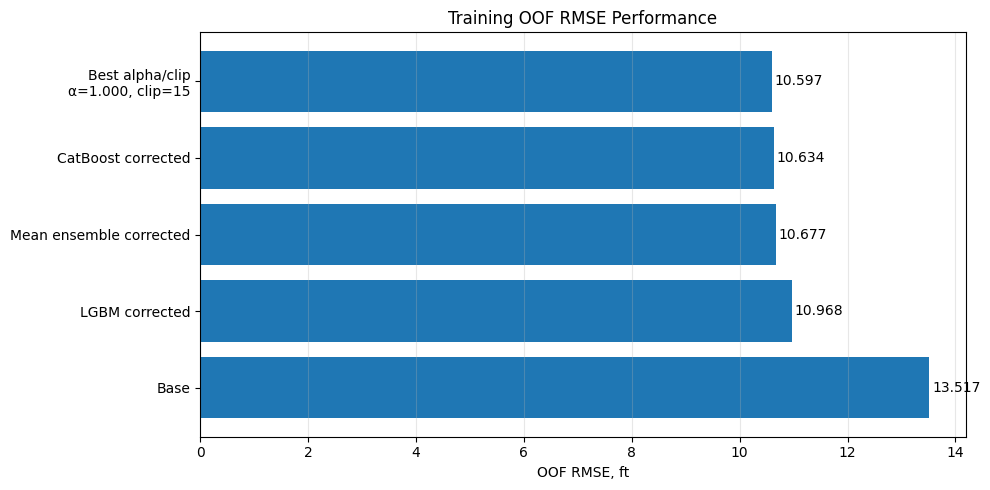

In [13]:
# ============================================================
# Plot OOF RMSE performance
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def build_oof_rmse_summary(resid_df, artifacts):
    base_pred = resid_df["base_pred"].values.astype(float)
    y_tvt = resid_df["target_tvt"].values.astype(float)

    rows = []

    rows.append({
        "model": "Base",
        "rmse_ft": rmse(y_tvt, base_pred)
    })

    if artifacts.get("has_cat", False):
        oof_cat = artifacts["oof_cat"]
        rows.append({
            "model": "CatBoost corrected",
            "rmse_ft": rmse(y_tvt, base_pred + oof_cat)
        })

    if artifacts.get("has_lgb", False):
        oof_lgb = artifacts["oof_lgb"]
        rows.append({
            "model": "LGBM corrected",
            "rmse_ft": rmse(y_tvt, base_pred + oof_lgb)
        })

    if artifacts.get("has_extra", False):
        oof_extra = artifacts["oof_extra"]
        rows.append({
            "model": "ExtraTrees corrected",
            "rmse_ft": rmse(y_tvt, base_pred + oof_extra)
        })

    if "oof_resid" in artifacts:
        oof_resid = artifacts["oof_resid"]
        rows.append({
            "model": "Mean ensemble corrected",
            "rmse_ft": rmse(y_tvt, base_pred + oof_resid)
        })

    if "alpha_df" in artifacts:
        best_row = artifacts["alpha_df"].sort_values("oof_rmse").iloc[0]
        rows.append({
            "model": f"Best alpha/clip\nα={best_row['alpha']:.3f}, clip={best_row['resid_clip']:g}",
            "rmse_ft": float(best_row["oof_rmse"])
        })

    return pd.DataFrame(rows).sort_values("rmse_ft", ascending=False)


rmse_summary_df = build_oof_rmse_summary(resid_df, artifacts)
display(rmse_summary_df)

plt.figure(figsize=(10, 5))
bars = plt.barh(rmse_summary_df["model"], rmse_summary_df["rmse_ft"])

plt.xlabel("OOF RMSE, ft")
plt.title("Training OOF RMSE Performance")
plt.grid(axis="x", alpha=0.3)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# 10. Prediction helpers
# ============================================================

def predict_residual(features, final_models):
    feature_cols = final_models["feature_cols"]
    cat_cols = final_models["cat_cols"]

    pred_dict = {}

    if final_models.get("cat_model") is not None:
        X_cat = align_features_for_model(features, feature_cols).copy().replace([np.inf, -np.inf], np.nan)
        for c in cat_cols:
            X_cat[c] = X_cat[c].astype(str).fillna("UNK")
        pred_dict["cat"] = np.asarray(final_models["cat_model"].predict(X_cat), dtype=float)

    if final_models.get("lgb_model") is not None:
        X_lgb, _ = prepare_for_lgb(
            features, feature_cols, cat_cols,
            category_maps=final_models["lgb_maps"],
            fit=False,
        )
        pred_dict["lgb"] = np.asarray(final_models["lgb_model"].predict(X_lgb), dtype=float)

    if final_models.get("extra_model") is not None:
        X_extra, _ = prepare_for_lgb(
            features, feature_cols, cat_cols,
            category_maps=final_models["extra_maps"],
            fit=False,
        )
        pred_dict["extra"] = np.asarray(final_models["extra_model"].predict(X_extra), dtype=float)

    if not pred_dict:
        return np.zeros(len(features), dtype=float)

    weights = final_models.get("resid_blend_weights", None)

    # Use optimized weighted blend if available
    if weights is not None:
        out = np.zeros(len(features), dtype=float)
        total_w = 0.0

        for name, pred in pred_dict.items():
            w = float(weights.get(name, 0.0))
            if w != 0.0:
                out += w * pred
                total_w += w

        if total_w > 0:
            return out / total_w

    # Fallback: simple mean ensemble
    return np.mean(
        np.vstack([np.asarray(p, dtype=float) for p in pred_dict.values()]),
        axis=0
    )


def smooth_predicted_section(hw, pred, blend=0.20, window=31, poly=2):
    out = np.asarray(pred, dtype=float).copy()
    mask = hw["TVT_input"].isna().values
    idx = np.where(mask)[0]
    if len(idx) < max(7, window):
        return out
    w = min(window, len(idx) if len(idx) % 2 == 1 else len(idx) - 1)
    if w < poly + 2:
        return out
    sm = savgol_filter(out[idx], window_length=w, polyorder=min(poly, w - 1))
    out[idx] = (1.0 - blend) * out[idx] + blend * sm
    return out


def predict_one_well(hw, tw, wid="", n_seeds=PF_SEEDS_SUBMIT):
    hw = sort_by_md_if_needed(hw)

    pf_by_scale = run_pf_lik_ensemble_scales(
        hw, tw,
        scales=CFG.PF_SCALES,
        n_particles=PF_PARTICLES,
        n_seeds=n_seeds,
    )

    if CFG.USE_BEAM:
        beam_pred = run_beam_ensemble(hw, tw)
    else:
        beam_pred = pf_by_scale[f"pf_scale_{CFG.BASE_SCALE:g}"].copy()

    base_pred = make_base_prediction(pf_by_scale, beam_pred, hw)
    eval_mask = hw["TVT_input"].isna().values

    if eval_mask.sum() == 0:
        return base_pred

    feat = build_ml_features(
        hw, tw, pf_by_scale, beam_pred, base_pred,
        rows_mask=eval_mask,
        well_id=wid,
    )
    resid = predict_residual(feat, final_models)

    clip = float(final_models.get("best_clip", np.inf))
    if CFG.APPLY_RESIDUAL_CLIPPING and np.isfinite(clip):
        resid = np.clip(resid, -clip, clip)
    
    alpha = float(final_models["best_alpha"])
    
    final_pred = base_pred.copy()
    final_pred[eval_mask] = base_pred[eval_mask] + alpha * resid
    if CFG.SMOOTH_SUBMISSION:
        final_pred = smooth_predicted_section(
            hw,
            final_pred,
            blend=CFG.SMOOTH_BLEND,
            window=CFG.SMOOTH_WINDOW,
            poly=CFG.SMOOTH_POLY,
    )
    return final_pred


In [15]:
# ============================================================
# 11. Create submission.csv
# ============================================================

train_wids_set = set(TRAIN_WELLS)
rows = []
t0 = time.time()

if len(TEST_WELLS) == 0:
    print("No usable test wells found. Skipping submission generation.")
else:
    # Process only wells required by sample_submission and available in test file maps.
    for wi, wid in enumerate(TEST_WELLS, start=1):
        print(f"\n[{wi}/{len(TEST_WELLS)}] Processing {wid}...")
        try:
            hw_te, tw_te = load_well(wid, "test")
            hw_te = sort_by_md_if_needed(hw_te)
        except Exception as e:
            print(f"  ERROR loading test well {wid}: {e}")
            continue

        pred = None

        if CFG.USE_VISIBLE_WELL_PHYSICAL_MODEL and wid in train_wids_set:
            try:
                hw_tr, tw_tr = load_well(wid, "train")
                phys = tvt_from_contacts(hw_tr, tw_tr)
                if phys is not None and len(phys) == len(hw_te):
                    pred = np.asarray(phys, dtype=float)
                    print("  using visible-well physical contact model")
                else:
                    print("  visible-well physical model skipped due to length mismatch")
            except Exception as e:
                print("  visible-well physical model failed:", e)

        if pred is None:
            try:
                pred = predict_one_well(hw_te, tw_te, wid=wid, n_seeds=PF_SEEDS_SUBMIT)
                print("  using PF/beam + ML residual")
            except Exception as e:
                print(f"  ERROR predicting well {wid}: {e}")
                # Conservative fallback: hold last known TVT_input or zero.
                last_known = hw_te["TVT_input"].dropna() if "TVT_input" in hw_te.columns else pd.Series(dtype=float)
                fallback = float(last_known.iloc[-1]) if len(last_known) else 0.0
                pred = np.full(len(hw_te), fallback, dtype=float)

        ws = sample[sample["well"].astype(str) == str(wid)]
        bad_rows = 0
        for _, row in ws.iterrows():
            ridx = int(row["row_idx"])
            if 0 <= ridx < len(pred):
                val = float(pred[ridx])
            else:
                bad_rows += 1
                val = np.nan
            rows.append({"id": row["id"], "tvt": val})

        if bad_rows:
            print(f"  WARNING: {bad_rows} row_idx values out of range for {wid}")
        print(f"  added {len(ws)} submission rows")
        gc.collect()

    submission = pd.DataFrame(rows)
    submission = sample[["id"]].merge(submission, on="id", how="left")

    if submission["tvt"].isna().any():
        missing = int(submission["tvt"].isna().sum())
        print(f"WARNING: {missing} missing predictions. Filling with median/zero fallback.")
        med = submission["tvt"].median()
        if not np.isfinite(med):
            med = 0.0
        submission["tvt"] = submission["tvt"].fillna(med)

    submission.to_csv("submission.csv", index=False)
    print(f"\nDone. submission.csv rows={len(submission):,}. elapsed={(time.time() - t0)/60:.1f} min")
    display(submission.head())



[1/3] Processing 000d7d20...
  using visible-well physical contact model
  added 3836 submission rows

[2/3] Processing 00bbac68...
  using visible-well physical contact model
  added 6014 submission rows

[3/3] Processing 00e12e8b...
  using visible-well physical contact model
  added 4301 submission rows

Done. submission.csv rows=14,151. elapsed=0.0 min


,id,tvt
0,000d7d20_1442,11747.378624
1,000d7d20_1443,11747.388624
2,000d7d20_1444,11747.398624
3,000d7d20_1445,11747.408624
4,000d7d20_1446,11747.418624


## Notes for stronger runs

This fixed version changes the fragile parts of the notebook while keeping the physical/PF/beam base model intact.

Important defaults in this fixed version:

```python
CFG.QUICK_RUN = False
CFG.FAKE_PS_FRACS_FULL = (0.70, 0.80, 0.90)
CFG.PF_SEEDS_OOF_FULL = 64
CFG.PF_SEEDS_SUBMIT_FULL = 128
CFG.PF_SCALES = (2.0, 3.0, 5.0, 8.0, 12.0, 16.0)
CFG.APPLY_RESIDUAL_CLIPPING = True
```

What was fixed:

- robust public/private Kaggle data discovery
- file maps across official and added datasets
- support for `wid__typewell.csv` and `wid__typewell__TypewellXXXX.csv`
- test wells driven by `sample_submission.csv`
- safe feature alignment at prediction time
- residual clip + alpha OOF search
- safer typewell GR derivative when duplicate TVT values exist
- safer submission row indexing and fallback behavior

For debugging, you can temporarily set `CFG.QUICK_RUN = True`, but serious leaderboard submissions should use full settings.


### Efficient residual-task mode

This version adds `CFG.RESIDUAL_TASK_MODE`:

- `"real_ps"`: fastest and usually most representative. It uses the original training `TVT_input` Prediction Start and evaluates rows after that PS. This gives one PF/beam task per well.
- `"fake_ps"`: the older multi-fraction synthetic setup.
- `"hybrid"`: combines real-PS and fake-PS rows.

`CFG.USE_ROW_SUBSAMPLING_FOR_RESIDUAL_TRAIN=True` keeps the full task RMSE diagnostic, but caps how many rows from each task are used for CatBoost/LGBM training. This reduces memory and training time without changing PF/beam base prediction logic.



### Residual-row cache added

This version caches each processed residual task under `CFG.RESIDUAL_CACHE_ROOT / "residual_rows"`.
The cache is keyed by a fingerprint of the settings that affect PF/beam/features, so changing important settings automatically creates a new cache folder.

Useful switches:

```python
CFG.USE_RESIDUAL_ROW_CACHE = True
CFG.REBUILD_RESIDUAL_ROW_CACHE = False  # set True only when you want to force rebuild
CFG.RESIDUAL_FEATURE_CACHE_TAG = "v5_realps_update_cache1"  # change this if you edit feature code
```

If a 773-well run stops halfway, rerun the notebook with the same settings and it will load the completed wells/tasks from cache and continue the rest.


### External residual-row cache read-first mode

This version now checks an external Kaggle Dataset cache before building new residual rows. Change this path yourself when you upload your cache dataset:

```python
CFG.EXTERNAL_RESIDUAL_CACHE_ROOT = Path("/kaggle/input/datasets/pannchobkitchakarn/foldername")
CFG.USE_EXTERNAL_RESIDUAL_ROW_CACHE = True
CFG.READ_EXTERNAL_RESIDUAL_CACHE_FIRST = True
```

The notebook checks these layouts under that folder:

```text
cache/residual_rows/<version>/...
residual_rows/<version>/...
<version>/...
real_ps/*.parquet directly inside the folder
```

If no matching external cache files are detected, the notebook simply builds missing wells/tasks and saves them to the writable working cache:

```text
/kaggle/working/cache/residual_rows/<version>/...
```

So the intended workflow is: run once to build `/kaggle/working/cache`, zip/upload that cache as a Kaggle Dataset, then set `CFG.EXTERNAL_RESIDUAL_CACHE_ROOT` to the uploaded dataset folder in future runs.
